# Data Injection #
**Description**
This Jupyter notebook is used to inject Data in excel or CSV format into firebase DB 

In [119]:

!pip install pandas --quiet
!pip install geopy --quiet
!pip -q install pycountry --quiet

In [120]:

import pandas as pd
import re
import numpy as np
import pandas as pd
import pycountry
import matplotlib.pyplot as plt
data_path = './dataset'


## Feature Engineering Configuration

Configuration constants for comprehensive feature engineering pipeline.

## Load the Transport Cost Data


In [121]:
TRANSPORT_PATH = f"{data_path}/TransportCosts.csv"
LSCI_PATH      = f"{data_path}/LSCI.csv"
LSBCI_PATH     = f"{data_path}/LSBCI.csv"
DIST_PATH      = f"{data_path}/dist_cepii.csv"
FUEL_PATH      = f"{data_path}/Daily_Bunker_Fuel_Prices.csv"


In [122]:
# -------------------------
# (B) ISO3 mapping helper
# -------------------------
manual_iso3 = {
  'Brunei Darussalam': 'BRN',
  'Cabo Verde': 'CPV',
  'China, Hong Kong SAR': 'HKG',
  'China, Macao SAR': 'MAC',
  'China, Taiwan Province of': 'TWN',
  'Congo, Dem. Rep. of the': 'COD',
  "Cote d'Ivoire": 'CIV',
  'Curaçao': 'CUW',
  'Curacao': 'CUW',
  'Eswatini': 'SWZ',
  "Korea, Dem. People's Rep. of": 'PRK',
  "Lao People's Dem. Rep.": 'LAO',
  'Netherlands (Kingdom of the)': 'NLD',
  'Russian Federation': 'RUS',
  'State of Palestine': 'PSE',
  'Türkiye': 'TUR',
  'Turkiye': 'TUR',
  'Venezuela (Bolivarian Rep. of)': 'VEN',
  'Viet Nam': 'VNM',
  'Bolivia (Plurinational State of)': 'BOL',
  'Iran (Islamic Republic of)': 'IRN',
  'Syrian Arab Republic': 'SYR',
  'United Republic of Tanzania': 'TZA',
  'Micronesia (Federated States of)': 'FSM',
  'Dem. Rep. of the Congo': 'COD',
  'Democratic Republic of the Congo': 'COD',
  "Côte d’Ivoire": 'CIV',
  "Côte d'Ivoire": 'CIV',
}

def to_iso3(label: str):
    if pd.isna(label):
        return None
    s = str(label).strip()
    if s in manual_iso3:
        return manual_iso3[s]
    # minimal normalization
    repl = {
        "Côte d'Ivoire": "Cote d'Ivoire",
        "Côte d’Ivoire": "Cote d'Ivoire",
    }
    s2 = repl.get(s, s)
    try:
        return pycountry.countries.lookup(s2).alpha_3
    except Exception:
        return None

# -------------------------
# (C) Load + melt transport costs (wide -> long)
# -------------------------
YEAR_RE = re.compile(r"(20\d{2})_Perunit_freight_rate_USkg_Value")

t = pd.read_csv(TRANSPORT_PATH)
year_cols = [c for c in t.columns if YEAR_RE.search(c)]
if not year_cols:
    raise ValueError("No year columns matched pattern: 20xx_Perunit_freight_rate_USkg_Value")

df_long = t.melt(
    id_vars=["Origin_Label","Destination_Label","Product_Code","Product_Label"],
    value_vars=year_cols,
    var_name="YearCol",
    value_name="Freight_USD_per_kg"
)
df_long["Year"] = df_long["YearCol"].str.extract(r"(20\d{2})").astype(int)
df_long.drop(columns=["YearCol"], inplace=True)

df_obs = df_long.dropna(subset=["Freight_USD_per_kg"]).copy()
df_obs["Freight_USD_per_kg"] = pd.to_numeric(df_obs["Freight_USD_per_kg"], errors="coerce")
df_obs = df_obs.dropna(subset=["Freight_USD_per_kg"])
df_obs = df_obs[df_obs["Freight_USD_per_kg"] >= 0].copy()
df_obs["y_log"] = np.log1p(df_obs["Freight_USD_per_kg"])

# ISO codes for joining externals
df_obs["iso_o"] = df_obs["Origin_Label"].map(to_iso3)
df_obs["iso_d"] = df_obs["Destination_Label"].map(to_iso3)

df_obs

,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d
3,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG
8,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG
9,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG
10,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG
12,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG
...,...,...,...,...,...,...,...,...,...
375516,United States of America,Zimbabwe,9404,Mattress supports; articles of bedding (e.g. m...,0.443,2021,0.366724,USA,ZWE
375517,Zambia,Zimbabwe,2106,Food preparations not elsewhere specified or i...,0.299,2021,0.261595,ZMB,ZWE
375518,Zambia,Zimbabwe,3304,"Cosmetic and toilet preparations; beauty, make...",0.170,2021,0.157004,ZMB,ZWE
375520,Zambia,Zimbabwe,8517,"Telephone sets, including telephones for cellu...",6.148,2021,1.966833,ZMB,ZWE


## Show Missing Destination Countries


In [123]:

# Get unique country sets from origin and destination
orig_countries = set(df_obs["Origin_Label"].unique())
dest_countries = set(df_obs["Destination_Label"].unique())

# Full master list of countries
all_countries = sorted(orig_countries | dest_countries)

# Build table
country_table = pd.DataFrame({"Country": all_countries})

# ISO3 code for each country
country_table["ISO3"] = country_table["Country"].map(to_iso3)


# Put the country name in Origin_Label / Destination_Label only if it appears there, else NaN
country_table["Origin_Label"] = country_table["Country"].where(
    country_table["Country"].isin(orig_countries)
)
country_table["Destination_Label"] = country_table["Country"].where(
    country_table["Country"].isin(dest_countries)
)
# country_table
print("These are the countries whereby no routes have them as destination")
country_table[country_table["Destination_Label"].isna()]



These are the countries whereby no routes have them as destination


,Country,ISO3,Origin_Label,Destination_Label
3,American Samoa,ASM,American Samoa,NaN
6,Anguilla,AIA,Anguilla,NaN
16,Bangladesh,BGD,Bangladesh,NaN
23,Bhutan,BTN,Bhutan,NaN
25,"Bonaire, Sint Eustatius and Saba",BES,"Bonaire, Sint Eustatius and Saba",NaN
29,British Virgin Islands,VGB,British Virgin Islands,NaN
37,Canada,CAN,Canada,NaN
40,Chad,TCD,Chad,NaN
45,"China, Taiwan Province of",TWN,"China, Taiwan Province of",NaN
46,Christmas Island,CXR,Christmas Island,NaN


## Load LSCI

**LSCI (Liner Shipping Connectivity Index)** is a country-level indicator that measures how well countries are connected to global liner shipping networks. Higher values indicate better integration into global maritime trade networks through container liner services. This index is used as a feature to help predict freight rates, since countries with better shipping connectivity typically have lower transport costs and more route options.

In [124]:
lsci = pd.read_csv(LSCI_PATH)

lsci
val_candidates = [c for c in lsci.columns if c.endswith("_Value")]

# sanity check: there should be only 1 column that ends with "_Value"
LSCI_VAL_COL = val_candidates[0]

# Extract year from Quarter_Label, convert LSCI value to numeric, and keep only relevant columns
lsci2 = lsci[["Economy_Label","Quarter_Label", LSCI_VAL_COL]].copy()
lsci2["Year"] = lsci2["Quarter_Label"].astype(str).str.extract(r"(20\d{2})").astype(int)
lsci2[LSCI_VAL_COL] = pd.to_numeric(lsci2[LSCI_VAL_COL], errors="coerce")

# Average LSCI per year per country computed from quarterly data, then mapped to ISO3 code
lsci_year = (
    lsci2.groupby(["Economy_Label","Year"], as_index=False)[LSCI_VAL_COL]
    .mean()
    .rename(columns={LSCI_VAL_COL:"lsci"})
)
lsci_year["iso3"] = lsci_year["Economy_Label"].map(to_iso3)
lsci_year
lsci_global_mean = float(lsci_year["lsci"].mean())


# Join to df_obs
tmp = df_obs.merge(
    lsci_year.rename(columns={"iso3":"iso_o","lsci":"lsci_o"})[["iso_o","Year","lsci_o"]],
    on=["iso_o","Year"], how="left"
).merge(
    lsci_year.rename(columns={"iso3":"iso_d","lsci":"lsci_d"})[["iso_d","Year","lsci_d"]],
    on=["iso_d","Year"], how="left"
)


# fill missing LSCI values with global mean, then compute sum and gap
# tmp["lsci_o"] = tmp["lsci_o"].fillna(lsci_global_mean)
# tmp["lsci_d"] = tmp["lsci_d"].fillna(lsci_global_mean)
# tmp["lsci_sum"] = tmp["lsci_o"] + tmp["lsci_d"]
# tmp["lsci_gap"] = (tmp["lsci_o"] - tmp["lsci_d"]).abs()

tmp

,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d,lsci_o,lsci_d
0,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG,388.5575,NaN
1,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG,914.0075,NaN
2,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG,914.0075,NaN
3,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG,914.0075,NaN
4,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG,342.9600,NaN
...,...,...,...,...,...,...,...,...,...,...,...
277058,United States of America,Zimbabwe,9404,Mattress supports; articles of bedding (e.g. m...,0.443,2021,0.366724,USA,ZWE,517.3300,NaN
277059,Zambia,Zimbabwe,2106,Food preparations not elsewhere specified or i...,0.299,2021,0.261595,ZMB,ZWE,NaN,NaN
277060,Zambia,Zimbabwe,3304,"Cosmetic and toilet preparations; beauty, make...",0.170,2021,0.157004,ZMB,ZWE,NaN,NaN
277061,Zambia,Zimbabwe,8517,"Telephone sets, including telephones for cellu...",6.148,2021,1.966833,ZMB,ZWE,NaN,NaN


## Load LSBCI

**LSBCI (Liner Shipping Bilateral Connectivity Index)** measures the strength of shipping connectivity between pairs of countries (bilateral relationships). Unlike LSCI which is a country-level index, LSBCI captures the direct shipping links between origin and destination countries. Higher LSBCI values indicate stronger bilateral shipping connections, which typically result in lower freight costs and more efficient trade routes between those specific country pairs.

In [125]:
lsbci = pd.read_csv(LSBCI_PATH)

lsbci

LSBCI_VAL_COL = [c for c in lsbci.columns if c.endswith("Index_Value")][0]

lsbci2 = lsbci[["Economy_Label","Partner_Label", LSBCI_VAL_COL]].copy()

lsbci2[LSBCI_VAL_COL] = pd.to_numeric(lsbci2[LSBCI_VAL_COL], errors="coerce")
lsbci2["iso_o"] = lsbci2["Economy_Label"].map(to_iso3)
lsbci2["iso_d"] = lsbci2["Partner_Label"].map(to_iso3)
lsbci2 = lsbci2.rename(columns={LSBCI_VAL_COL:"lsbci"})[["iso_o","iso_d","lsbci"]].dropna(subset=["iso_o","iso_d"])
lsbci2 = lsbci2.groupby(["iso_o","iso_d"], as_index=False)["lsbci"].mean()

tmp = tmp.merge(lsbci2, on=["iso_o","iso_d"], how="left")

# # fill missing
# tmp["lsbci"] = tmp["lsbci"].fillna(0.0)
tmp

,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d,lsci_o,lsci_d,lsbci
0,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG,388.5575,NaN,NaN
1,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG,914.0075,NaN,NaN
2,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG,914.0075,NaN,NaN
3,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG,914.0075,NaN,NaN
4,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG,342.9600,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
277058,United States of America,Zimbabwe,9404,Mattress supports; articles of bedding (e.g. m...,0.443,2021,0.366724,USA,ZWE,517.3300,NaN,NaN
277059,Zambia,Zimbabwe,2106,Food preparations not elsewhere specified or i...,0.299,2021,0.261595,ZMB,ZWE,NaN,NaN,NaN
277060,Zambia,Zimbabwe,3304,"Cosmetic and toilet preparations; beauty, make...",0.170,2021,0.157004,ZMB,ZWE,NaN,NaN,NaN
277061,Zambia,Zimbabwe,8517,"Telephone sets, including telephones for cellu...",6.148,2021,1.966833,ZMB,ZWE,NaN,NaN,NaN


## Load Distance

In [126]:
dist = pd.read_csv(DIST_PATH)


dist

# convert "." to NaN then numeric
for c in ["distw","distwces","dist","distcap"]:
    if c in dist.columns:
        dist[c] = pd.to_numeric(dist[c].replace(".", np.nan), errors="coerce")


# choose best distance
if "distw" in dist.columns:
    dist["dist_km"] = dist["distw"].fillna(dist.get("dist", np.nan))
else:
    dist["dist_km"] = dist.get("dist", np.nan)

# sanity check: there should be no zero or negative distances, if any, set to NaN
dist2 = dist[["iso_o","iso_d","dist_km"]].dropna(subset=["iso_o","iso_d"]).copy()
dist2.loc[dist2["dist_km"] <= 0, "dist_km"] = np.nan
dist_median = float(dist2["dist_km"].median())

tmp = tmp.merge(dist2, on=["iso_o","iso_d"], how="left")
print("Distance coverage (pre-fill):", tmp["dist_km"].notna().mean())

# Load country centroids for geographic distance calculation
centroids_path = f"{data_path}/country_centroids.csv"

from geopy.distance import geodesic

centroids = pd.read_csv(centroids_path)
centroids["iso3"] = centroids["Country"].map(to_iso3)

# Clean centroids: keep only rows with valid ISO3 codes and finite coordinates
centroids = centroids.dropna(subset=["iso3", "Lat", "Lon"])
centroids = centroids[
    (centroids["Lat"].notna()) & 
    (centroids["Lon"].notna()) &
    (np.isfinite(centroids["Lat"])) &
    (np.isfinite(centroids["Lon"]))
].copy()

# Create lookup dictionaries for coordinates
centroid_coords = dict(zip(centroids["iso3"], zip(centroids["Lat"], centroids["Lon"])))

print(f"Loaded {len(centroid_coords)} country centroids for distance calculation")

# Function to calculate geodesic distance
def calculate_geodesic_distance(iso_o, iso_d):
    # Check if both ISO codes are valid (not NaN) and exist in our lookup
    if pd.notna(iso_o) and pd.notna(iso_d) and iso_o in centroid_coords and iso_d in centroid_coords:
        origin_coords = centroid_coords[iso_o]
        dest_coords = centroid_coords[iso_d]
        # Double-check coordinates are finite before passing to geodesic
        if all(np.isfinite(c) for c in origin_coords + dest_coords):
            return geodesic(origin_coords, dest_coords).kilometers
    return np.nan

# Fill missing distances with calculated geographic distances
mask = tmp["dist_km"].isna()
if mask.sum() > 0:
    print(f"Calculating geographic distances for {mask.sum()} missing values...")
    tmp.loc[mask, "dist_km"] = tmp[mask].apply(
        lambda row: calculate_geodesic_distance(row["iso_o"], row["iso_d"]), 
        axis=1
    )
    print(f"Distance coverage (after centroid calculation):", tmp["dist_km"].notna().mean())

missing = tmp["dist_km"].isna().sum()
print(f"Number of missing distances after geographic calculation: {missing}")

# Fill any remaining missing distances with median
# tmp["dist_km"] = tmp["dist_km"].fillna(dist_median)
# tmp["log_dist"] = np.log1p(tmp["dist_km"])

# Derived feature: lsbci per km
tmp["lsbci_per_km"] = tmp["lsbci"] / tmp["dist_km"]

# print(f"Final distance coverage: {tmp['dist_km'].notna().mean():.2%}")
# print(f"Distance statistics: min={tmp['dist_km'].min():.1f}, median={tmp['dist_km'].median():.1f}, max={tmp['dist_km'].max():.1f}")

tmp

Distance coverage (pre-fill): 0.7941262456553203
Loaded 211 country centroids for distance calculation
Calculating geographic distances for 57040 missing values...
Distance coverage (after centroid calculation): 0.8345033440047931
Number of missing distances after geographic calculation: 45853


,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d,lsci_o,lsci_d,lsbci,dist_km,lsbci_per_km
0,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG,388.5575,NaN,NaN,5331.8920,NaN
1,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG,914.0075,NaN,NaN,4434.3820,NaN
2,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG,914.0075,NaN,NaN,4434.3820,NaN
3,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG,914.0075,NaN,NaN,4434.3820,NaN
4,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG,342.9600,NaN,NaN,5189.4990,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277058,United States of America,Zimbabwe,9404,Mattress supports; articles of bedding (e.g. m...,0.443,2021,0.366724,USA,ZWE,517.3300,NaN,NaN,14160.5500,NaN
277059,Zambia,Zimbabwe,2106,Food preparations not elsewhere specified or i...,0.299,2021,0.261595,ZMB,ZWE,NaN,NaN,NaN,583.7954,NaN
277060,Zambia,Zimbabwe,3304,"Cosmetic and toilet preparations; beauty, make...",0.170,2021,0.157004,ZMB,ZWE,NaN,NaN,NaN,583.7954,NaN
277061,Zambia,Zimbabwe,8517,"Telephone sets, including telephones for cellu...",6.148,2021,1.966833,ZMB,ZWE,NaN,NaN,NaN,583.7954,NaN


## Load Fuel

**VLSFO (Very Low Sulfur Fuel Oil)** is a marine fuel with a maximum sulfur content of 0.5%, mandated by the International Maritime Organization (IMO) 2020 regulations. Prior to 2020, ships used higher sulfur fuels (up to 3.5% sulfur). VLSFO pricing directly affects shipping costs, as fuel represents a significant portion of total freight expenses. This feature captures fuel price fluctuations over time as a key cost driver in freight rate predictions.

In [127]:

fuel = pd.read_csv(FUEL_PATH)

# detect VLSFO column
fuel_candidates = [c for c in fuel.columns if "VLSFO" in c]
FUEL_COL = fuel_candidates[0]

fuel[FUEL_COL] = pd.to_numeric(fuel[FUEL_COL].replace(r"[\$,]", "", regex=True), errors="coerce")
fuel_year = (
    fuel.groupby("Year", as_index=False)[FUEL_COL].mean()
    .rename(columns={FUEL_COL:"fuel_vlsfo_avg"})
)

# Fill 2016-2018 using 2019 average (Option B)
fuel_2019 = fuel_year.loc[fuel_year["Year"] == 2019, "fuel_vlsfo_avg"]
fuel_fill = float(fuel_2019.iloc[0]) if len(fuel_2019) else float(fuel_year["fuel_vlsfo_avg"].mean())

for y in [2016, 2017, 2018]:
    if y not in set(fuel_year["Year"]):
        fuel_year = pd.concat([fuel_year, pd.DataFrame({"Year":[y], "fuel_vlsfo_avg":[fuel_fill]})], ignore_index=True)

fuel_year = fuel_year.sort_values("Year").reset_index(drop=True)

tmp = tmp.merge(fuel_year, on="Year", how="left")
# tmp["fuel_vlsfo_avg"] = tmp["fuel_vlsfo_avg"].fillna(fuel_fill)

tmp

,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d,lsci_o,lsci_d,lsbci,dist_km,lsbci_per_km,fuel_vlsfo_avg
0,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG,388.5575,NaN,NaN,5331.8920,NaN,576.846774
1,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG,914.0075,NaN,NaN,4434.3820,NaN,576.846774
2,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG,914.0075,NaN,NaN,4434.3820,NaN,576.846774
3,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG,914.0075,NaN,NaN,4434.3820,NaN,576.846774
4,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG,342.9600,NaN,NaN,5189.4990,NaN,576.846774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
277058,United States of America,Zimbabwe,9404,Mattress supports; articles of bedding (e.g. m...,0.443,2021,0.366724,USA,ZWE,517.3300,NaN,NaN,14160.5500,NaN,544.296935
277059,Zambia,Zimbabwe,2106,Food preparations not elsewhere specified or i...,0.299,2021,0.261595,ZMB,ZWE,NaN,NaN,NaN,583.7954,NaN,544.296935
277060,Zambia,Zimbabwe,3304,"Cosmetic and toilet preparations; beauty, make...",0.170,2021,0.157004,ZMB,ZWE,NaN,NaN,NaN,583.7954,NaN,544.296935
277061,Zambia,Zimbabwe,8517,"Telephone sets, including telephones for cellu...",6.148,2021,1.966833,ZMB,ZWE,NaN,NaN,NaN,583.7954,NaN,544.296935


## Load CPI data by source and destination country

**CPI (Consumer Price Index)** measures the average change over time in the prices paid by consumers for a basket of goods and services. The annual average growth rate indicates inflation levels in each country. In freight modeling, CPI is important because inflation affects purchasing power, production costs, and ultimately trade volumes between countries. Higher inflation in source or destination countries can influence freight demand and pricing dynamics.

In [52]:
cpi_data_path = f"{data_path}/CPI.csv"
df_cpi = pd.read_csv(cpi_data_path)

# Drop aggregate row that is not a real economy
df_cpi = df_cpi[df_cpi["Economy_Label"] != "Individual economies"].copy()

# Ensure Year is numeric/int so it matches tmp["Year"]
df_cpi["Year"] = pd.to_numeric(df_cpi["Year"], errors="coerce")
df_cpi = df_cpi.dropna(subset=["Year"])
df_cpi["Year"] = df_cpi["Year"].astype(int)

# Keep only the columns we need
df_cpi = df_cpi[["Economy_Label", "Year", "Annual_average_growth_rate_Value"]].copy()

# Merge source-country CPI onto tmp (Origin_Label + Year)
tmp = tmp.merge(
    df_cpi.rename(columns={"Annual_average_growth_rate_Value": "Source_CPI_Annual_average_growth_rate_Value"}),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

# Merge destination-country CPI onto tmp (Destination_Label + Year)
tmp = tmp.merge(
    df_cpi.rename(columns={"Annual_average_growth_rate_Value": "Destination_CPI_Annual_average_growth_rate_Value"}),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

# Quick peek at the result with CPI columns added
tmp.head()

,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d,lsci_o,lsci_d,lsci_sum,lsci_gap,lsbci,dist_km,log_dist,lsbci_per_km,fuel_vlsfo_avg,Source_CPI_Annual_average_growth_rate_Value,Destination_CPI_Annual_average_growth_rate_Value
0,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG,388.5575,95.895008,484.452508,292.662492,0.0,5331.892,8.581649,0.0,576.846774,1.77,2.12
1,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG,914.0075,95.895008,1009.902508,818.112492,0.0,4434.382,8.397369,0.0,576.846774,2.12,2.12
2,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG,914.0075,95.895008,1009.902508,818.112492,0.0,4434.382,8.397369,0.0,576.846774,2.12,2.12
3,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG,914.0075,95.895008,1009.902508,818.112492,0.0,4434.382,8.397369,0.0,576.846774,2.12,2.12
4,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG,342.9600,95.895008,438.855008,247.064992,0.0,5189.499,8.554585,0.0,576.846774,1.39,2.12


## Load GDP data by source and destination country

**GDP (Gross Domestic Product)** is the total monetary value of all goods and services produced within a country over a specific time period. It's the primary indicator of economic size and activity. In freight modeling, GDP is crucial because larger economies typically generate more trade volumes, have greater import/export capacity, and can afford higher shipping costs. The GDP of both source and destination countries helps predict trade intensity and freight demand on specific routes.

In [129]:
gdp_data_path = f"{data_path}/GDP.csv"
df_gdp = pd.read_csv(gdp_data_path)

# Drop aggregate row that is not a real economy
df_gdp = df_gdp[df_gdp["Economy_Label"] != "Individual economies"].copy()

# Ensure Year is numeric/int so it matches tmp["Year"]
df_gdp["Year"] = pd.to_numeric(df_gdp["Year"], errors="coerce")
df_gdp = df_gdp.dropna(subset=["Year"])
df_gdp["Year"] = df_gdp["Year"].astype(int)

# Keep only columns we need
df_gdp = df_gdp[["Economy_Label", "Year", "US_at_current_prices_in_millions_Value"]].copy()

# Merge source-country GDP onto tmp (Origin_Label + Year)
tmp = tmp.merge(
    df_gdp.rename(columns={"US_at_current_prices_in_millions_Value": "Source_GDP_US_at_current_prices_in_millions_Value"}),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

# Merge destination-country GDP onto tmp (Destination_Label + Year)
tmp = tmp.merge(
    df_gdp.rename(columns={"US_at_current_prices_in_millions_Value": "Destination_GDP_US_at_current_prices_in_millions_Value"}),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

# Quick peek at the result with GDP columns added
tmp.head()

,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d,lsci_o,lsci_d,lsbci,dist_km,lsbci_per_km,fuel_vlsfo_avg,Source_GDP_US_at_current_prices_in_millions_Value_x,Destination_GDP_US_at_current_prices_in_millions_Value_x,Source_GDP_US_at_current_prices_in_millions_Value_y,Destination_GDP_US_at_current_prices_in_millions_Value_y
0,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG,388.5575,NaN,NaN,5331.892,NaN,576.846774,474272.0,18224.0,474272.0,18224.0
1,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG,914.0075,NaN,NaN,4434.382,NaN,576.846774,11456024.0,18224.0,11456024.0,18224.0
2,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG,914.0075,NaN,NaN,4434.382,NaN,576.846774,11456024.0,18224.0,11456024.0,18224.0
3,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG,914.0075,NaN,NaN,4434.382,NaN,576.846774,11456024.0,18224.0,11456024.0,18224.0
4,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG,342.9600,NaN,NaN,5189.499,NaN,576.846774,543081.0,18224.0,543081.0,18224.0


## Load GNI data by source and destination country

**GNI (Gross National Income)** is the total income earned by a country's residents and businesses, including income from abroad, minus income paid to foreign entities. While GDP measures production within borders, GNI measures income belonging to a country's residents regardless of location. In freight modeling, GNI reflects a country's overall purchasing power and economic capacity for international trade, making it a complementary indicator to GDP for understanding trade potential and freight demand patterns.

In [130]:
gni_data_path = f"{data_path}/GNI.csv"
df_gni = pd.read_csv(gni_data_path)

# Drop aggregate row that is not a real economy
df_gni = df_gni[df_gni["Economy_Label"] != "Individual economies"].copy()

# Ensure Year is numeric/int so it matches tmp["Year"]
df_gni["Year"] = pd.to_numeric(df_gni["Year"], errors="coerce")
df_gni = df_gni.dropna(subset=["Year"])
df_gni["Year"] = df_gni["Year"].astype(int)

# Keep only columns we need
df_gni = df_gni[["Economy_Label", "Year", "US_dollars_at_current_prices_in_millions_Value"]].copy()

# Merge source-country GNI onto tmp (Origin_Label + Year)
tmp = tmp.merge(
    df_gni.rename(columns={"US_dollars_at_current_prices_in_millions_Value": "Source_GNI_US_dollars_at_current_prices_in_millions_Value"}),
    left_on=["Origin_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

 # Merge destination-country GNI onto tmp (Destination_Label + Year)
tmp = tmp.merge(
    df_gni.rename(columns={"US_dollars_at_current_prices_in_millions_Value": "Destination_GNI_US_dollars_at_current_prices_in_millions_Value"}),
    left_on=["Destination_Label", "Year"],
    right_on=["Economy_Label", "Year"],
    how="left",
)
tmp = tmp.drop(columns=["Economy_Label"])

 # Quick peek at the result with GNI columns added
tmp.head()
df=tmp.copy()

## Sanity Check

In [131]:
# No key duplication should occur
dup_rate = tmp.duplicated(subset=["Origin_Label","Destination_Label","Product_Code","Year"]).mean()
print("Duplicate rate on (Origin,Dest,Product,Year):", dup_rate)

# Quick coverage after fills (should be 0 missing for these)
check_cols = ["lsci_o","lsci_d","lsbci","dist_km","fuel_vlsfo_avg"]
print("Any NaN left in core engineered features?", tmp[check_cols].isna().any().any())

Duplicate rate on (Origin,Dest,Product,Year): 0.1355792725842137
Any NaN left in core engineered features? True


## Additional Feature Engineering (from 02_feature_engineering.ipynb)

Integrating missing features: port throughput (TEU), merchant fleet, seaborne trade, vessel percentages, historical mean rate, and derived features.

In [56]:
# ══════════════════════════════════════════════════════════════════════════════
# IDEMPOTENCY CHECK: Skip if features already exist
# ══════════════════════════════════════════════════════════════════════════════

_skip_features = all(col in tmp.columns for col in [
    "origin_teu", "origin_fleet_pct", "origin_vessel_pct", 
    "historical_mean_rate", "lsci_asymmetry"
])

if _skip_features:
    print("ℹ Cell 27 features already exist - skipping re-creation")
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE ENGINEERING PIPELINE
# Note: Re-running this cell will recreate features (safe with left joins)
# ══════════════════════════════════════════════════════════════════════════════

print("🔧 Feature engineering pipeline starting...\n")

# ══════════════════════════════════════════════════════════════════════════════
# Load Port Throughput (TEU) Data
# ══════════════════════════════════════════════════════════════════════════════

teu_path = f"{data_path}/../data/raw/container_port_throughput.csv"
try:
    df_teu_raw = pd.read_csv(teu_path)
    df_teu_raw = df_teu_raw[df_teu_raw["Economy_Label"] != "Individual economies"].copy()
    
    # Extract year columns
    teu_year_cols = [c for c in df_teu_raw.columns if "TEU_Twenty_foot_Equivalent_Unit_Value" in c and c[:4].isdigit()]
    
    # Melt to long format
    df_teu = df_teu_raw.melt(
        id_vars=["Economy_Label"],
        value_vars=teu_year_cols,
        var_name="_raw_col",
        value_name="teu"
    )
    df_teu["Year"] = df_teu["_raw_col"].str[:4].astype(int)
    df_teu = df_teu[["Economy_Label", "Year", "teu"]].copy()
    df_teu["teu"] = pd.to_numeric(df_teu["teu"], errors="coerce")
    
    # Normalize country names
    df_teu["iso3"] = df_teu["Economy_Label"].map(to_iso3)
    df_teu = df_teu.dropna(subset=["iso3"])
    
    # Merge for origin
    tmp = tmp.merge(
        df_teu.rename(columns={"iso3": "iso_o", "teu": "origin_teu"})[["iso_o", "Year", "origin_teu"]],
        on=["iso_o", "Year"],
        how="left"
    )
    tmp["origin_teu_is_imputed"] = tmp["origin_teu"].isna().astype(int)
    
    # Merge for destination
    tmp = tmp.merge(
        df_teu.rename(columns={"iso3": "iso_d", "teu": "dest_teu"})[["iso_d", "Year", "dest_teu"]],
        on=["iso_d", "Year"],
        how="left"
    )
    tmp["dest_teu_is_imputed"] = tmp["dest_teu"].isna().astype(int)
    
    # Fill missing with 0
    tmp["origin_teu"] = tmp["origin_teu"].fillna(0.0)
    tmp["dest_teu"] = tmp["dest_teu"].fillna(0.0)
    
    # Create derived feature: teu_log_product
    tmp["teu_log_product"] = np.log1p(tmp["origin_teu"]) * np.log1p(tmp["dest_teu"])
    
    print(f"✓ Port throughput (TEU) features added")
    print(f"  Origin TEU coverage: {(tmp['origin_teu_is_imputed'] == 0).mean():.2%}")
    print(f"  Destination TEU coverage: {(tmp['dest_teu_is_imputed'] == 0).mean():.2%}")
    
except Exception as e:
    print(f"⚠ Port throughput error: {e}")
    tmp["origin_teu"] = 0.0
    tmp["dest_teu"] = 0.0
    tmp["teu_log_product"] = 0.0
    tmp["origin_teu_is_imputed"] = 1
    tmp["dest_teu_is_imputed"] = 1
    
except Exception as e:
    print(f"⚠ Port throughput error: {e}")
    tmp["origin_teu"] = 0.0
    tmp["dest_teu"] = 0.0
    tmp["teu_log_product"] = 0.0
    tmp["origin_teu_is_imputed"] = 1
    tmp["dest_teu_is_imputed"] = 1

# ══════════════════════════════════════════════════════════════════════════════
# Load Merchant Fleet Data
# ══════════════════════════════════════════════════════════════════════════════

fleet_path = f"{data_path}/../data/raw/merchant_fleet.csv"
try:
    df_fleet_raw = pd.read_csv(fleet_path)
    df_fleet_raw = df_fleet_raw[df_fleet_raw["Economy_Label"] != "Individual economies"].copy()
    
    # Extract year columns
    fleet_year_cols = [c for c in df_fleet_raw.columns if "Percentage_of_total_world_Value" in c and c[:4].isdigit()]
    
    # Melt to long format
    df_fleet = df_fleet_raw.melt(
        id_vars=["Economy_Label"],
        value_vars=fleet_year_cols,
        var_name="_raw_col",
        value_name="fleet_pct"
    )
    df_fleet["Year"] = df_fleet["_raw_col"].str[:4].astype(int)
    df_fleet = df_fleet[["Economy_Label", "Year", "fleet_pct"]].copy()
    df_fleet["fleet_pct"] = pd.to_numeric(df_fleet["fleet_pct"], errors="coerce")
    
    # Normalize country names
    df_fleet["iso3"] = df_fleet["Economy_Label"].map(to_iso3)
    df_fleet = df_fleet.dropna(subset=["iso3"])
    
    # Merge for origin and destination
    tmp = tmp.merge(
        df_fleet.rename(columns={"iso3": "iso_o", "fleet_pct": "origin_fleet_pct"})[["iso_o", "Year", "origin_fleet_pct"]],
        on=["iso_o", "Year"],
        how="left"
    ).merge(
        df_fleet.rename(columns={"iso3": "iso_d", "fleet_pct": "dest_fleet_pct"})[["iso_d", "Year", "dest_fleet_pct"]],
        on=["iso_d", "Year"],
        how="left"
    )
    
    # Fill missing with 0
    tmp["origin_fleet_pct"] = tmp["origin_fleet_pct"].fillna(0.0)
    tmp["dest_fleet_pct"] = tmp["dest_fleet_pct"].fillna(0.0)
    tmp["fleet_supply"] = tmp["origin_fleet_pct"] + tmp["dest_fleet_pct"]
    
    print(f"✓ Merchant fleet features added")
    print(f"  Origin fleet coverage: {(tmp['origin_fleet_pct'] > 0).mean():.2%}")
    
except Exception as e:
    print(f"⚠ Merchant fleet error: {e}")
    tmp["origin_fleet_pct"] = 0.0
    tmp["dest_fleet_pct"] = 0.0
    tmp["fleet_supply"] = 0.0

# ══════════════════════════════════════════════════════════════════════════════
# Load Seaborne Trade Data
# ══════════════════════════════════════════════════════════════════════════════

trade_path = f"{data_path}/../data/raw/seaborne_trade.csv"
try:
    df_trade_raw = pd.read_csv(trade_path)
    df_trade_raw = df_trade_raw[df_trade_raw["Economy_Label"] != "Individual economies"].copy()
    df_trade_raw = df_trade_raw.rename(columns={"CargoType_Label": "cargo_type"})
    
    # Extract year columns
    trade_year_cols = [c for c in df_trade_raw.columns if "Metric_tons_in_thousands_Value" in c and c[:4].isdigit()]
    
    # Melt to long format
    df_trade = df_trade_raw.melt(
        id_vars=["Economy_Label", "cargo_type"],
        value_vars=trade_year_cols,
        var_name="_raw_col",
        value_name="volume_kt"
    )
    df_trade["Year"] = df_trade["_raw_col"].str[:4].astype(int)
    df_trade["volume_kt"] = pd.to_numeric(df_trade["volume_kt"], errors="coerce")
    
    # Pivot to get loaded and discharged
    df_trade_pivot = df_trade.pivot_table(
        index=["Economy_Label", "Year"],
        columns="cargo_type",
        values="volume_kt",
        aggfunc="sum"
    ).reset_index()
    df_trade_pivot.columns.name = None
    
    # Identify loaded/discharged columns
    rename_map = {}
    for c in df_trade_pivot.columns:
        if isinstance(c, str):
            if "loaded" in c.lower() and "discharged" not in c.lower():
                rename_map[c] = "loaded_kt"
            elif "discharged" in c.lower():
                rename_map[c] = "discharged_kt"
    
    df_trade_pivot = df_trade_pivot.rename(columns=rename_map)
    for col in ["loaded_kt", "discharged_kt"]:
        if col not in df_trade_pivot.columns:
            df_trade_pivot[col] = 0.0
    
    # Normalize country names
    df_trade_pivot["iso3"] = df_trade_pivot["Economy_Label"].map(to_iso3)
    df_trade_pivot = df_trade_pivot.dropna(subset=["iso3"])
    
    # Merge for origin and destination
    tmp = tmp.merge(
        df_trade_pivot.rename(columns={
            "iso3": "iso_o",
            "loaded_kt": "origin_loaded_kt",
            "discharged_kt": "origin_discharged_kt"
        })[["iso_o", "Year", "origin_loaded_kt", "origin_discharged_kt"]],
        on=["iso_o", "Year"],
        how="left"
    ).merge(
        df_trade_pivot.rename(columns={
            "iso3": "iso_d",
            "loaded_kt": "dest_loaded_kt",
            "discharged_kt": "dest_discharged_kt"
        })[["iso_d", "Year", "dest_loaded_kt", "dest_discharged_kt"]],
        on=["iso_d", "Year"],
        how="left"
    )
    
    # Fill missing with 0
    for col in ["origin_loaded_kt", "origin_discharged_kt", "dest_loaded_kt", "dest_discharged_kt"]:
        tmp[col] = tmp[col].fillna(0.0)
    
    # Create derived feature: trade_imbalance
    tmp["trade_imbalance"] = (
        (tmp["origin_loaded_kt"] - tmp["dest_loaded_kt"])
        / (tmp["origin_loaded_kt"] + tmp["dest_loaded_kt"] + 1e-9)
    )
    
    print(f"✓ Seaborne trade features added")
    print(f"  Origin loaded coverage: {(tmp['origin_loaded_kt'] > 0).mean():.2%}")
    
except Exception as e:
    print(f"⚠ Seaborne trade error: {e}")
    for col in ["origin_loaded_kt", "origin_discharged_kt", "dest_loaded_kt", "dest_discharged_kt"]:
        tmp[col] = 0.0
    tmp["trade_imbalance"] = 0.0

# ══════════════════════════════════════════════════════════════════════════════
# Load Vessel Percentage Data
# ══════════════════════════════════════════════════════════════════════════════

vessel_path = f"{data_path}/../data/raw/vessel_percent_of_global_fleet.csv"
try:
    df_vessel_raw = pd.read_csv(vessel_path)
    df_vessel_raw = df_vessel_raw[df_vessel_raw["FlagOfRegistration_Label"] != "Individual economies"].copy()
    df_vessel_raw = df_vessel_raw.rename(columns={"FlagOfRegistration_Label": "country"})
    
    # Extract year columns
    vessel_year_cols = [c for c in df_vessel_raw.columns if "Percentage_of_global_fleet_value_Value" in c and c[:4].isdigit()]
    
    # Melt to long format
    df_vessel = df_vessel_raw.melt(
        id_vars=["country"],
        value_vars=vessel_year_cols,
        var_name="_raw_col",
        value_name="vessel_pct"
    )
    df_vessel["Year"] = df_vessel["_raw_col"].str[:4].astype(int)
    df_vessel["vessel_pct"] = pd.to_numeric(df_vessel["vessel_pct"], errors="coerce")
    
    # Back-fill 2016-2018 with 2019 values
    df_2019 = df_vessel[df_vessel["Year"] == 2019][["country", "vessel_pct"]].copy()
    extra_rows = []
    for yr in [2016, 2017, 2018]:
        tmp_yr = df_2019.copy()
        tmp_yr["Year"] = yr
        extra_rows.append(tmp_yr)
    
    df_vessel = pd.concat([df_vessel] + extra_rows, ignore_index=True)
    df_vessel["iso3"] = df_vessel["country"].map(to_iso3)
    df_vessel = df_vessel.dropna(subset=["iso3"])
    
    # Merge for origin and destination
    tmp = tmp.merge(
        df_vessel.rename(columns={"iso3": "iso_o", "vessel_pct": "origin_vessel_pct"})[["iso_o", "Year", "origin_vessel_pct"]],
        on=["iso_o", "Year"],
        how="left"
    ).merge(
        df_vessel.rename(columns={"iso3": "iso_d", "vessel_pct": "dest_vessel_pct"})[["iso_d", "Year", "dest_vessel_pct"]],
        on=["iso_d", "Year"],
        how="left"
    )
    
    # Fill missing with 0
    tmp["origin_vessel_pct"] = tmp["origin_vessel_pct"].fillna(0.0)
    tmp["dest_vessel_pct"] = tmp["dest_vessel_pct"].fillna(0.0)
    
    print(f"✓ Vessel percentage features added")
    print(f"  Origin vessel coverage: {(tmp['origin_vessel_pct'] > 0).mean():.2%}")
    
except Exception as e:
    print(f"⚠ Vessel percentage error: {e}")
    tmp["origin_vessel_pct"] = 0.0
    tmp["dest_vessel_pct"] = 0.0

# ══════════════════════════════════════════════════════════════════════════════
# Create Historical Mean Rate Feature
# ══════════════════════════════════════════════════════════════════════════════

if "Freight_USD_per_kg" in tmp.columns:
    historical_obs = tmp[
        tmp["Freight_USD_per_kg"].notna() & tmp["Year"].isin([2016, 2017, 2018, 2019])
    ].copy()
    
    grp_mean = (
        historical_obs
        .groupby(["Origin_Label", "Destination_Label", "Product_Code"])["Freight_USD_per_kg"]
        .mean()
        .rename("historical_mean_rate")
    )
    
    tmp = tmp.set_index(["Origin_Label", "Destination_Label", "Product_Code"]).join(grp_mean).reset_index()
    
    product_medians = (
        tmp[tmp["Freight_USD_per_kg"].notna()]
        .groupby("Product_Code")["Freight_USD_per_kg"]
        .median()
    )
    
    tmp["historical_mean_rate_is_imputed"] = tmp["historical_mean_rate"].isna().astype(int)
    
    for prod, med in product_medians.items():
        mask = (tmp["Product_Code"] == prod) & tmp["historical_mean_rate"].isna()
        tmp.loc[mask, "historical_mean_rate"] = med
    
    tmp["historical_mean_rate"] = tmp["historical_mean_rate"].fillna(tmp["Freight_USD_per_kg"].median())
    
    print(f"✓ historical_mean_rate feature added")
    print(f"  Imputation rate: {tmp['historical_mean_rate_is_imputed'].mean():.2%}")
else:
    tmp["historical_mean_rate"] = 0.0
    tmp["historical_mean_rate_is_imputed"] = 1

# ══════════════════════════════════════════════════════════════════════════════
# Create Additional Derived Features
# ══════════════════════════════════════════════════════════════════════════════

tmp["lsci_asymmetry"] = (tmp["lsci_o"] - tmp["lsci_d"]).abs()
tmp["post_covid"] = (tmp["Year"] >= 2020).astype(int)
tmp["year_int"] = tmp["Year"].astype(int)

if "Product_Code" in tmp.columns:
    unique_products = sorted(tmp["Product_Code"].unique())
    tmp["product_cat"] = (
        tmp["Product_Code"]
        .astype("category")
        .cat.set_categories(unique_products)
        .cat.codes
        .astype(int)
    )
else:
    tmp["product_cat"] = 0

# Create imputation flag for bilateral LSCI
if "bilateral_lsci_is_imputed" not in tmp.columns:
    tmp["bilateral_lsci_is_imputed"] = (tmp["lsbci"] == 0.0).astype(int)

# Create aliases for consistency with 02_feature_engineering
feature_name_mapping = {
    "lsci_o": "origin_lsci",
    "lsci_d": "dest_lsci",
    "lsbci": "bilateral_lsci"
}

for old_name, new_name in feature_name_mapping.items():
    if old_name in tmp.columns and new_name not in tmp.columns:
        tmp[new_name] = tmp[old_name]

# Update df reference
df = tmp.copy()

print(f"\n{'=' * 80}")
print(f"✅ FEATURE ENGINEERING COMPLETE")
print(f"{'=' * 80}")
print(f"  Total features: {len(tmp.columns)}")
print(f"  Dataset shape: {tmp.shape}")
print(f"\n  New features added:")
print(f"    - TEU (port throughput): origin_teu, dest_teu, teu_log_product")
print(f"    - Merchant fleet: origin_fleet_pct, dest_fleet_pct, fleet_supply")
print(f"    - Seaborne trade: 4 volume cols + trade_imbalance")
print(f"    - Vessel percentages: origin_vessel_pct, dest_vessel_pct")
print(f"    - Historical rate: historical_mean_rate")
print(f"    - Derived: lsci_asymmetry, post_covid, year_int, product_cat")
print(f"    - Imputation flags: 4 tracking flags")
print(f"{'=' * 80}\n")

tmp.head()

🔧 Feature engineering pipeline starting...

✓ Port throughput (TEU) features added
  Origin TEU coverage: 74.82%
  Destination TEU coverage: 65.76%
✓ Merchant fleet features added
  Origin fleet coverage: 50.03%
✓ Seaborne trade features added
  Origin loaded coverage: 88.07%
✓ Vessel percentage features added
  Origin vessel coverage: 67.89%
✓ historical_mean_rate feature added
  Imputation rate: 2.55%

✅ FEATURE ENGINEERING COMPLETE
  Total features: 49
  Dataset shape: (284555, 49)

  New features added:
    - TEU (port throughput): origin_teu, dest_teu, teu_log_product
    - Merchant fleet: origin_fleet_pct, dest_fleet_pct, fleet_supply
    - Seaborne trade: 4 volume cols + trade_imbalance
    - Vessel percentages: origin_vessel_pct, dest_vessel_pct
    - Historical rate: historical_mean_rate
    - Derived: lsci_asymmetry, post_covid, year_int, product_cat
    - Imputation flags: 4 tracking flags



,Origin_Label,Destination_Label,Product_Code,Product_Label,Freight_USD_per_kg,Year,y_log,iso_o,iso_d,lsci_o,...,historical_mean_rate,historical_mean_rate_is_imputed,lsci_asymmetry,post_covid,year_int,product_cat,bilateral_lsci_is_imputed,origin_lsci,dest_lsci,bilateral_lsci
0,Belgium,Afghanistan,2106,Food preparations not elsewhere specified or i...,0.227,2016,0.204572,BEL,AFG,388.5575,...,0.22600,0,292.662492,0,2016,0,1,388.5575,95.895008,0.0
1,China,Afghanistan,3304,"Cosmetic and toilet preparations; beauty, make...",0.644,2016,0.497132,CHN,AFG,914.0075,...,0.44350,0,818.112492,0,2016,1,1,914.0075,95.895008,0.0
2,China,Afghanistan,8517,"Telephone sets, including telephones for cellu...",18.245,2016,2.957251,CHN,AFG,914.0075,...,8.78425,0,818.112492,0,2016,3,1,914.0075,95.895008,0.0
3,China,Afghanistan,9404,Mattress supports; articles of bedding (e.g. m...,0.608,2016,0.474991,CHN,AFG,914.0075,...,0.58600,0,818.112492,0,2016,4,1,914.0075,95.895008,0.0
4,"China, Taiwan Province of",Afghanistan,8517,"Telephone sets, including telephones for cellu...",26.985,2016,3.331669,TWN,AFG,342.9600,...,14.18125,0,247.064992,0,2016,3,1,342.9600,95.895008,0.0


## Pipeline Configuration

All hyper-parameters and shared preprocessing run here once. A per-product **KNN analog model** (`route_knn`) is also built after preprocessing — it is used at prediction time to impute lag proxies for new routes with no historical observations (Option A).


In [57]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════
#  CONFIGURATION — edit once to tune the full per-product pipeline
# ══════════════════════════════════════════════════════════════════

TARGET = "y_log"   # log1p(Freight_USD_per_kg); back-transform with np.expm1()

FEATURE_COLS = [
    # Original economic features
    "Source_CPI_Annual_average_growth_rate_Value",
    "Destination_CPI_Annual_average_growth_rate_Value",
    "Source_GDP_US_at_current_prices_in_millions_Value",
    "Destination_GDP_US_at_current_prices_in_millions_Value",
    "Source_GNI_US_dollars_at_current_prices_in_millions_Value",
    "Destination_GNI_US_dollars_at_current_prices_in_millions_Value",
    # Original connectivity and cost features
    "lsbci", "dist_km", "fuel_vlsfo_avg",
    "lsci_o", "lsci_d", "lsci_sum", "lsci_gap",
    # Port throughput (TEU) features
    "origin_teu", "dest_teu", "teu_log_product", 
    "origin_teu_is_imputed", "dest_teu_is_imputed",
    # Merchant fleet features
    "origin_fleet_pct", "dest_fleet_pct", "fleet_supply",
    # Seaborne trade features
    "origin_loaded_kt", "origin_discharged_kt", 
    "dest_loaded_kt", "dest_discharged_kt", "trade_imbalance",
    # Vessel percentage features
    "origin_vessel_pct", "dest_vessel_pct",
    # Historical rate feature
    "historical_mean_rate", "historical_mean_rate_is_imputed",
    # Derived features
    "lsci_asymmetry", "post_covid", "year_int", "product_cat",
    # Imputation tracking
    "bilateral_lsci_is_imputed",
]

GROUP_COLS       = ["Origin_Label", "Destination_Label", "Product_Code"]
TIME_COL         = "Year"
TEST_SPLIT_YEARS = 1     # last N years held out as test set

# XGBoost hyper-parameters
XGB_PARAMS = dict(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    early_stopping_rounds=30, eval_metric="mae",
)

# TFT hyper-parameters
TFT_PARAMS = dict(
    learning_rate=3e-3, hidden_size=32, attention_head_size=2,
    dropout=0.1, hidden_continuous_size=16, output_size=7,
    log_interval=-1, reduce_on_plateau_patience=4,
)

MAX_PREDICTION_LENGTH = 2
MAX_ENCODER_LENGTH    = 4
MIN_SERIES_LEN        = 6
N_EPOCHS              = 5
BATCH_SIZE            = 64

# Option A — KNN configuration
# Features used to find analogous routes for lag-proxy imputation
KNN_K     = 5
KNN_FEATS = [
    "dist_km", "lsci_sum", "lsbci",
    "Source_GDP_US_at_current_prices_in_millions_Value",
    "Destination_GDP_US_at_current_prices_in_millions_Value",
]

# ══════════════════════════════════════════════════════════════════
#  COMMON PREPROCESSING  (runs once across all products)
# ══════════════════════════════════════════════════════════════════

SELECT_COLS = list(dict.fromkeys(GROUP_COLS + [TIME_COL] + FEATURE_COLS + [TARGET]))

df_model = df[SELECT_COLS].copy()
df_model = df_model[df_model[TARGET].notna()].reset_index(drop=True)
df_model[TIME_COL] = df_model[TIME_COL].astype(int)
df_model = df_model.sort_values(GROUP_COLS + [TIME_COL]).reset_index(drop=True)

# Global outlier clipping on log-target (p1 – p99)
_lower = df_model[TARGET].quantile(0.01)
_upper = df_model[TARGET].quantile(0.99)
df_model[TARGET] = df_model[TARGET].clip(lower=_lower, upper=_upper)
print(f"Target clipped to [{_lower:.4f}, {_upper:.4f}]  (p1–p99)")

# Lag + rolling-mean features within each group
for _lag in [1, 2, 3]:
    df_model[f"target_lag_{_lag}"] = df_model.groupby(GROUP_COLS)[TARGET].shift(_lag)

df_model["target_rolling_mean_3"] = (
    df_model.groupby(GROUP_COLS)[TARGET]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# Global label encoders (needed so XGBoost sees consistent integer codes)
le_origin  = LabelEncoder().fit(df_model["Origin_Label"])
le_dest    = LabelEncoder().fit(df_model["Destination_Label"])
le_product = LabelEncoder().fit(df_model["Product_Code"].astype(str))

df_model["origin_enc"]  = le_origin.transform(df_model["Origin_Label"])
df_model["dest_enc"]    = le_dest.transform(df_model["Destination_Label"])
df_model["product_enc"] = le_product.transform(df_model["Product_Code"].astype(str))

XGB_FEATURES = (
    FEATURE_COLS
    + ["target_lag_1", "target_lag_2", "target_lag_3", "target_rolling_mean_3"]
    + ["origin_enc", "dest_enc", "product_enc", TIME_COL]
)

# Fill remaining NaN (lag/rolling edges) with column medians
df_model[XGB_FEATURES] = df_model[XGB_FEATURES].fillna(
    df_model[XGB_FEATURES].median(numeric_only=True)
)

max_year   = df_model[TIME_COL].max()
split_year = max_year - TEST_SPLIT_YEARS
PRODUCTS   = sorted(df_model["Product_Code"].unique())

print(f"\nProducts      : {PRODUCTS}")
print(f"Temporal split: train ≤ {split_year}  |  test = {max_year}")
print(f"Total rows    : {len(df_model)}")

# ══════════════════════════════════════════════════════════════════
#  OPTION A — Per-product KNN analog model
#  Represents each known route as its time-averaged structural
#  feature vector and fits a NearestNeighbors model per product.
#  At prediction time the k nearest analog routes are retrieved
#  and their mean y_log is used as the lag proxy.
# ══════════════════════════════════════════════════════════════════

route_knn = {}   # keyed by product_code

for _product in PRODUCTS:
    _sub = df_model[df_model["Product_Code"] == _product]
    _route_means = (
        _sub.groupby(["Origin_Label", "Destination_Label"])[KNN_FEATS + [TARGET]]
        .mean()
        .reset_index()
    )
    _X_raw    = _route_means[KNN_FEATS].fillna(_route_means[KNN_FEATS].median())
    _k_actual = min(KNN_K, len(_route_means))
    if _k_actual >= 2:
        _knn_sc = StandardScaler().fit(_X_raw)
        _knn    = NearestNeighbors(n_neighbors=_k_actual, metric="euclidean")
        _knn.fit(_knn_sc.transform(_X_raw))
        route_knn[_product] = {
            "knn":         _knn,
            "knn_scaler":  _knn_sc,
            "route_means": _route_means,
        }

print(f"\nOption A KNN analog models built for {len(route_knn)} product(s).")


Target clipped to [0.0649, 4.5790]  (p1–p99)

Products      : [np.int64(2106), np.int64(3304), np.int64(6109), np.int64(8517), np.int64(9404)]
Temporal split: train ≤ 2020  |  test = 2021
Total rows    : 284555

Option A KNN analog models built for 5 product(s).


## Step 1 — Preprocessing Pipeline Function

`preprocess_product(product_code)` filters `df_model` to a single product, performs a temporal train/test split, fits a `StandardScaler` on the training slice (for XGBoost), and builds the TFT-format DataFrame (unscaled, `GroupNormalizer` handles TFT normalisation internally).


In [58]:

def preprocess_product(product_code):
    """Filter, scale, and prepare data for a single product.

    Returns
    -------
    (df_train, df_test, df_tft_p)  or  None if data is insufficient.

    df_train / df_test  — FEATURE_COLS are StandardScaler-transformed
                          (scaler fit on train, applied to test).
    df_tft_p            — Unscaled copy with 'group_id' (Origin|Dest)
                          and 'time_idx' columns; short series removed.
    """
    sub = df_model[df_model["Product_Code"] == product_code].copy()

    df_train = sub[sub[TIME_COL] <= split_year].copy()
    df_test  = sub[sub[TIME_COL] >  split_year].copy()

    if len(df_train) < 2 or len(df_test) < 2:
        return None

    # StandardScaler: fit on train, transform test (XGBoost only)
    scaler = StandardScaler()
    df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])
    df_test[FEATURE_COLS]  = scaler.transform(df_test[FEATURE_COLS])

    # TFT-ready slice — unscaled; GroupNormalizer handles its own scaling
    df_tft_p = df_model[df_model["Product_Code"] == product_code].copy()
    _min_yr  = df_tft_p[TIME_COL].min()

    df_tft_p["group_id"]  = (
        df_tft_p["Origin_Label"].astype(str) + "|"
        + df_tft_p["Destination_Label"].astype(str)
    )
    df_tft_p["time_idx"]   = df_tft_p[TIME_COL] - _min_yr
    df_tft_p["group_id"]   = df_tft_p["group_id"].astype(str)
    df_tft_p["Product_Code"] = df_tft_p["Product_Code"].astype(str)

    # Remove series shorter than MIN_SERIES_LEN
    _slen    = df_tft_p.groupby("group_id")["time_idx"].count()
    df_tft_p = df_tft_p[
        df_tft_p["group_id"].isin(_slen[_slen >= MIN_SERIES_LEN].index)
    ].reset_index(drop=True)

    return df_train, df_test, df_tft_p


print("preprocess_product() ready.")


preprocess_product() ready.


## Step 2 — XGBoost Training Function

`train_xgboost_product(df_train, df_test)` trains an `XGBRegressor` on one product's split and returns the fitted model, predictions, and a metrics dict (log scale + USD/kg scale).


In [59]:

def train_xgboost_product(df_train, df_test):
    """Train XGBoost on a single product's train/test split.

    Returns
    -------
    model    : fitted XGBRegressor
    y_pred   : np.ndarray of predictions on df_test (y_log scale)
    metrics  : dict — mae_log, rmse_log, r2_log, mae_usd, rmse_usd,
                      mean_actual_usd, n_test
    """
    X_train, y_train = df_train[XGB_FEATURES], df_train[TARGET]
    X_test,  y_test  = df_test[XGB_FEATURES],  df_test[TARGET]

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred = model.predict(X_test)

    metrics = {
        "mae_log":         mean_absolute_error(y_test, y_pred),
        "rmse_log":        np.sqrt(mean_squared_error(y_test, y_pred)),
        "r2_log":          r2_score(y_test, y_pred),
        "mae_usd":         mean_absolute_error(np.expm1(y_test), np.expm1(y_pred)),
        "rmse_usd":        np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred))),
        "mean_actual_usd": float(np.expm1(y_test).mean()),
        "n_test":          int(len(y_test)),
    }
    return model, y_pred, metrics


print("train_xgboost_product() ready.")


train_xgboost_product() ready.


## Step 3 — TFT Training Function

`train_tft_product(df_tft_p, product_code)` builds a per-product `TimeSeriesDataSet` (each series = one Origin–Destination pair), trains a `TemporalFusionTransformer`, aligns the validation predictions back to actual `time_idx` values, and returns metrics in the same log-scale space as XGBoost.  
Returns `None` if fewer than 2 qualifying series exist for the product.


In [60]:

import lightning.pytorch as pl
import torch
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss


# ── Helpers ───────────────────────────────────────────────────────────────────

def _get_tft_preds(model, val_ldr):
    """Single inference pass with return_index=True.

    Returns (preds_np [N, H], idx_df or None).
    Using return_index=True means group_ids come back as decoded strings —
    no dependency on categorical_encoders (which may be None in newer versions).
    """
    out = model.predict(val_ldr, mode="prediction", return_index=True)

    preds_t, idx_df = None, None

    if hasattr(out, "prediction") and hasattr(out, "index"):
        preds_t, idx_df = out.prediction, out.index
    elif hasattr(out, "output") and hasattr(out, "index"):
        preds_t, idx_df = out.output, out.index
    elif isinstance(out, (list, tuple)):
        for item in out:
            if isinstance(item, pd.DataFrame) and idx_df is None:
                idx_df = item
            elif isinstance(item, torch.Tensor) and preds_t is None:
                preds_t = item
        if preds_t is None and out:
            preds_t = out[0]
    else:
        preds_t = out

    if preds_t is None:
        return None, None

    preds_np = preds_t.cpu().numpy()
    if preds_np.ndim == 3:
        preds_np = preds_np[:, :, 3]       # median quantile (index 3 = 0.5)
    elif preds_np.ndim == 1:
        preds_np = preds_np.reshape(-1, 1)

    return preds_np, idx_df


def _build_aligned_df(preds_np, idx_df, t0, df_tft_p, TARGET):
    """Map raw prediction array → DataFrame(group_id, time_idx, y_pred).

    t0 = first decoder time_idx (training_cutoff + 1), equal for all groups
    because every group ends at the same max_time_idx within a product.

    Strategy 1 — idx_df: find the column whose values contain "|"
                  (our group_id separator), regardless of column name.
                  Works whether the column is 'group_id',
                  '__group_id__group_id', or anything else.
    Strategy 2 — sorted fallback: if idx_df is missing or unusable,
                  assume the DataLoader emits groups in sorted order.
    """
    n, horizon = preds_np.shape

    if idx_df is not None and isinstance(idx_df, pd.DataFrame) and len(idx_df) == n:
        # Locate the group_id column by looking for the "|" separator
        g_col = None
        for c in idx_df.columns:
            if len(idx_df) > 0 and "|" in str(idx_df[c].iloc[0]):
                g_col = c
                break
        if g_col is None:
            # Fallback within idx_df: first object-dtype column
            g_col = next((c for c in idx_df.columns if idx_df[c].dtype == object), None)

        if g_col is not None:
            rows = []
            for i in range(n):
                gid = str(idx_df.iloc[i][g_col])
                for h in range(horizon):
                    rows.append({"group_id": gid,
                                 "time_idx": t0 + h,
                                 "y_pred":   float(preds_np[i, h])})
            return pd.DataFrame(rows)

    # Sorted fallback — val DataLoader with shuffle=False is deterministic
    val_groups = sorted(df_tft_p[df_tft_p["time_idx"] < t0]["group_id"].unique())
    if len(val_groups) == n:
        rows = [
            {"group_id": gid, "time_idx": t0 + h, "y_pred": float(preds_np[i, h])}
            for i, gid in enumerate(val_groups) for h in range(horizon)
        ]
        return pd.DataFrame(rows)

    return None


# ── Main TFT training function ────────────────────────────────────────────────

def train_tft_product(df_tft_p, product_code):
    """Build TimeSeriesDataSet and train TFT for one product.

    Each time-series = one Origin–Destination pair within the product.
    mode="prediction" applies GroupNormalizer.inverse_transform so output
    is in y_log space, directly comparable to XGBoost.
    """
    if df_tft_p is None or df_tft_p["group_id"].nunique() < 2:
        return None

    _max_t      = df_tft_p["time_idx"].max()
    _cutoff     = _max_t - MAX_PREDICTION_LENGTH
    _t0         = _cutoff + 1              # first decoder time_idx (same for all groups)
    _train_grps = df_tft_p.loc[df_tft_p["time_idx"] <= _cutoff, "group_id"].unique()
    df_tft_p    = df_tft_p[df_tft_p["group_id"].isin(_train_grps)].reset_index(drop=True)

    if df_tft_p["group_id"].nunique() < 2:
        return None

    try:
        training_ds = TimeSeriesDataSet(
            df_tft_p[df_tft_p["time_idx"] <= _cutoff],
            time_idx="time_idx",
            target=TARGET,
            group_ids=["group_id"],
            min_encoder_length=MAX_ENCODER_LENGTH // 2,
            max_encoder_length=MAX_ENCODER_LENGTH,
            min_prediction_length=1,
            max_prediction_length=MAX_PREDICTION_LENGTH,
            static_categoricals=["group_id"],
            time_varying_known_reals=["time_idx"],
            time_varying_unknown_reals=FEATURE_COLS + [TARGET],
            target_normalizer=GroupNormalizer(groups=["group_id"], transformation="softplus"),
            add_relative_time_idx=True,
            add_target_scales=True,
            add_encoder_length=True,
            allow_missing_timesteps=True,
        )
        val_ds = TimeSeriesDataSet.from_dataset(
            training_ds, df_tft_p, predict=True, stop_randomization=True)
        train_ldr = training_ds.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=0)
        val_ldr   = val_ds.to_dataloader(    train=False, batch_size=BATCH_SIZE, num_workers=0)

        model = TemporalFusionTransformer.from_dataset(
            training_ds, **TFT_PARAMS, loss=QuantileLoss())
        trainer = pl.Trainer(
            max_epochs=N_EPOCHS, accelerator="auto",
            gradient_clip_val=0.1, enable_progress_bar=False,
            logger=False, enable_checkpointing=False,
        )
        trainer.fit(model, train_dataloaders=train_ldr, val_dataloaders=val_ldr)

        # Inference — return_index=True gives string group_ids in idx_df directly
        preds_np, idx_df = _get_tft_preds(model, val_ldr)
        if preds_np is None:
            return None

        aligned = _build_aligned_df(preds_np, idx_df, _t0, df_tft_p, TARGET)
        if aligned is None:
            return None

        # Join actuals from df_tft_p
        _lu = df_tft_p[["group_id", "time_idx", TARGET]].drop_duplicates(
            subset=["group_id", "time_idx"])
        aligned = aligned.merge(_lu, on=["group_id", "time_idx"], how="inner")
        aligned["Product_Code"] = product_code

        if len(aligned) < 2:
            return None

        y_act, y_prd = aligned[TARGET].values, aligned["y_pred"].values
        metrics = {
            "mae_log":         mean_absolute_error(y_act, y_prd),
            "rmse_log":        np.sqrt(mean_squared_error(y_act, y_prd)),
            "r2_log":          r2_score(y_act, y_prd),
            "mae_usd":         mean_absolute_error(np.expm1(y_act), np.expm1(y_prd)),
            "rmse_usd":        np.sqrt(mean_squared_error(np.expm1(y_act), np.expm1(y_prd))),
            "mean_actual_usd": float(np.expm1(y_act).mean()),
            "n_test":          int(len(y_act)),
        }
        return model, aligned, metrics

    except Exception as e:
        print(f"    [TFT error for {product_code}]: {e}")
        return None


print("train_tft_product() and helpers ready.")


train_tft_product() and helpers ready.


## Step 4 — Run Per-Product Pipeline

Iterates over every product code, calls `preprocess_product` → `train_xgboost_product` → `train_tft_product`, and accumulates all results in `pipeline_results`.

> **Note:** TFT trains `N_EPOCHS` epochs per product. Reduce `N_EPOCHS` or set `SKIP_TFT = True` below to speed up a trial run.


In [61]:

SKIP_TFT = False   # set True to run XGBoost-only (much faster for quick testing)

pipeline_results = {}   # keyed by product_code

for _product in PRODUCTS:
    print(f"\n{'═' * 60}")
    print(f"  Product : {_product}")
    print(f"{'═' * 60}")

    _prep = preprocess_product(_product)
    if _prep is None:
        print("  → Skipped (insufficient train or test rows).")
        continue
    _df_train_p, _df_test_p, _df_tft_p = _prep

    _n_series = _df_tft_p["group_id"].nunique() if _df_tft_p is not None else 0
    print(f"  Train rows : {len(_df_train_p):,}  |  "
          f"Test rows : {len(_df_test_p):,}  |  "
          f"TFT series : {_n_series}")

    # ── XGBoost ──────────────────────────────────────────────────────────────
    _xm, _xpred, _xmet = train_xgboost_product(_df_train_p, _df_test_p)
    print(f"  XGBoost  →  MAE(log)={_xmet['mae_log']:.4f}  "
          f"R²={_xmet['r2_log']:.4f}  "
          f"MAE(USD/kg)={_xmet['mae_usd']:.4f}")

    # ── TFT ──────────────────────────────────────────────────────────────────
    _tm = _taln = _tmet = None
    if not SKIP_TFT:
        print(f"  TFT      →  training ({N_EPOCHS} epochs)…")
        pl.seed_everything(42, verbose=False)
        _tft_res = train_tft_product(_df_tft_p, _product)
        if _tft_res is not None:
            _tm, _taln, _tmet = _tft_res
            print(f"  TFT      →  MAE(log)={_tmet['mae_log']:.4f}  "
                  f"R²={_tmet['r2_log']:.4f}  "
                  f"MAE(USD/kg)={_tmet['mae_usd']:.4f}")
        else:
            print("  TFT      →  skipped (< 2 qualifying series).")
    else:
        print("  TFT      →  skipped (SKIP_TFT=True).")

    pipeline_results[_product] = {
        "xgb_model":   _xm,
        "xgb_pred":    _xpred,
        "xgb_metrics": _xmet,
        "tft_model":   _tm,
        "tft_aligned": _taln,
        "tft_metrics": _tmet,
        "df_train":    _df_train_p,
        "df_test":     _df_test_p,
    }

print(f"\n{'═' * 60}")
print(f"Pipeline complete — {len(pipeline_results)} product(s) processed.")



════════════════════════════════════════════════════════════
  Product : 2106
════════════════════════════════════════════════════════════
  Train rows : 45,572  |  Test rows : 9,678  |  TFT series : 5257
  XGBoost  →  MAE(log)=0.2699  R²=0.2801  MAE(USD/kg)=0.9647
  TFT      →  training (5 epochs)…


c:\Users\xianj\anaconda3\Lib\site-packages\pytorch_forecasting\data\timeseries\_timeseries.py:1859: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 64 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_id': 'Algeria|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'Argentina|Germany'}, {'__group_id__group_id': 'Bahamas|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'Bahrain|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'Belarus|Germany'}, {'__group_id__group_id': 'Belarus|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'Benin|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'Bermuda|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'Bolivia (Plurinational State of)|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'Cameroon|Switzerland, Liechtenstein'}]
  

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  167 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.3 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 93.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 324 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 324 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 804                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try inst

...

c:\Users\xianj\anaconda3\Lib\site-packages\pytorch_forecasting\data\timeseries\_timeseries.py:1859: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 93 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_id': 'Afghanistan|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'Algeria|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'Andorra|Germany'}, {'__group_id__group_id': 'Armenia|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'Belize|Germany'}, {'__group_id__group_id': 'Bolivia (Plurinational State of)|Germany'}, {'__group_id__group_id': 'Chile|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'Colombia|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'El Salvador|Switzerland, Liechtenstein'}, {'__group_id__group_id': 'Eswatini|Switzerland, Liechtenstein'}]
  warnings.warn

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  125 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.3 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.0 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 93.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 282 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 282 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 804                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\xianj\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=5` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try inst

  TFT      →  MAE(log)=0.2164  R²=0.2714  MAE(USD/kg)=0.5389

════════════════════════════════════════════════════════════
Pipeline complete — 5 product(s) processed.


In [62]:

# ── Aggregate per-product metrics into a summary table ───────────────────────
_rows = []
for _prod, _res in pipeline_results.items():
    _row = {
        "Product_Code":         _prod,
        "Mean Actual (USD/kg)": _res["xgb_metrics"]["mean_actual_usd"],
        "n_test":               _res["xgb_metrics"]["n_test"],
    }
    for _k, _v in _res["xgb_metrics"].items():
        if _k not in ("mean_actual_usd", "n_test"):
            _row[f"XGB_{_k}"] = _v
    _tm = _res["tft_metrics"]
    for _k in ["mae_log", "rmse_log", "r2_log", "mae_usd", "rmse_usd"]:
        _row[f"TFT_{_k}"] = _tm[_k] if _tm else float("nan")
    _rows.append(_row)

df_summary = pd.DataFrame(_rows).set_index("Product_Code")

_col_order = [
    "Mean Actual (USD/kg)", "n_test",
    "XGB_mae_log", "XGB_rmse_log", "XGB_r2_log", "XGB_mae_usd", "XGB_rmse_usd",
    "TFT_mae_log", "TFT_rmse_log", "TFT_r2_log", "TFT_mae_usd", "TFT_rmse_usd",
]
df_summary = df_summary[[c for c in _col_order if c in df_summary.columns]]

print("═" * 90)
print("Per-Product Pipeline Results")
print("═" * 90)
print(df_summary.round(4).to_string())


══════════════════════════════════════════════════════════════════════════════════════════
Per-Product Pipeline Results
══════════════════════════════════════════════════════════════════════════════════════════
              Mean Actual (USD/kg)  n_test  XGB_mae_log  XGB_rmse_log  XGB_r2_log  XGB_mae_usd  XGB_rmse_usd  TFT_mae_log  TFT_rmse_log  TFT_r2_log  TFT_mae_usd  TFT_rmse_usd
Product_Code                                                                                                                                                                  
2106                        1.5389    9678       0.2699        0.4458      0.2801       0.9647        4.4019       0.2200        0.3709      0.2110       0.5625        2.4804
3304                        2.7733    9152       0.4111        0.5792      0.2198       1.8171        6.3978       0.2940        0.4622      0.3118       1.0705        4.3749
6109                        5.1462   10044       0.3638        0.5158      0.3111       2

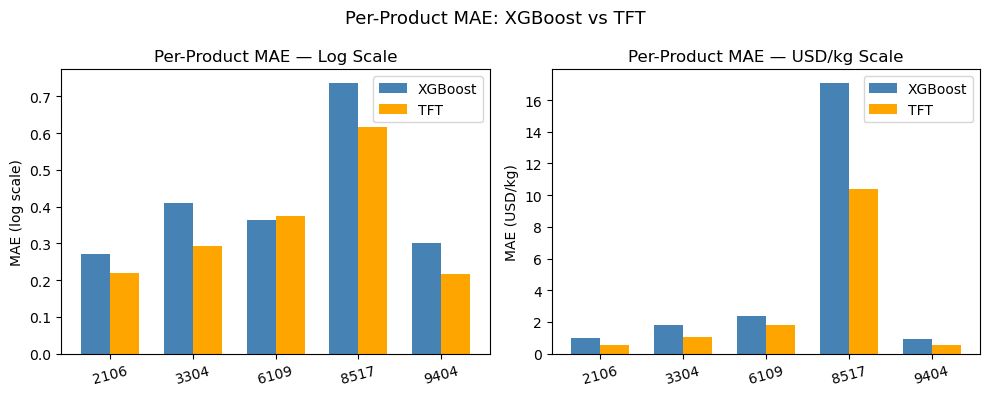

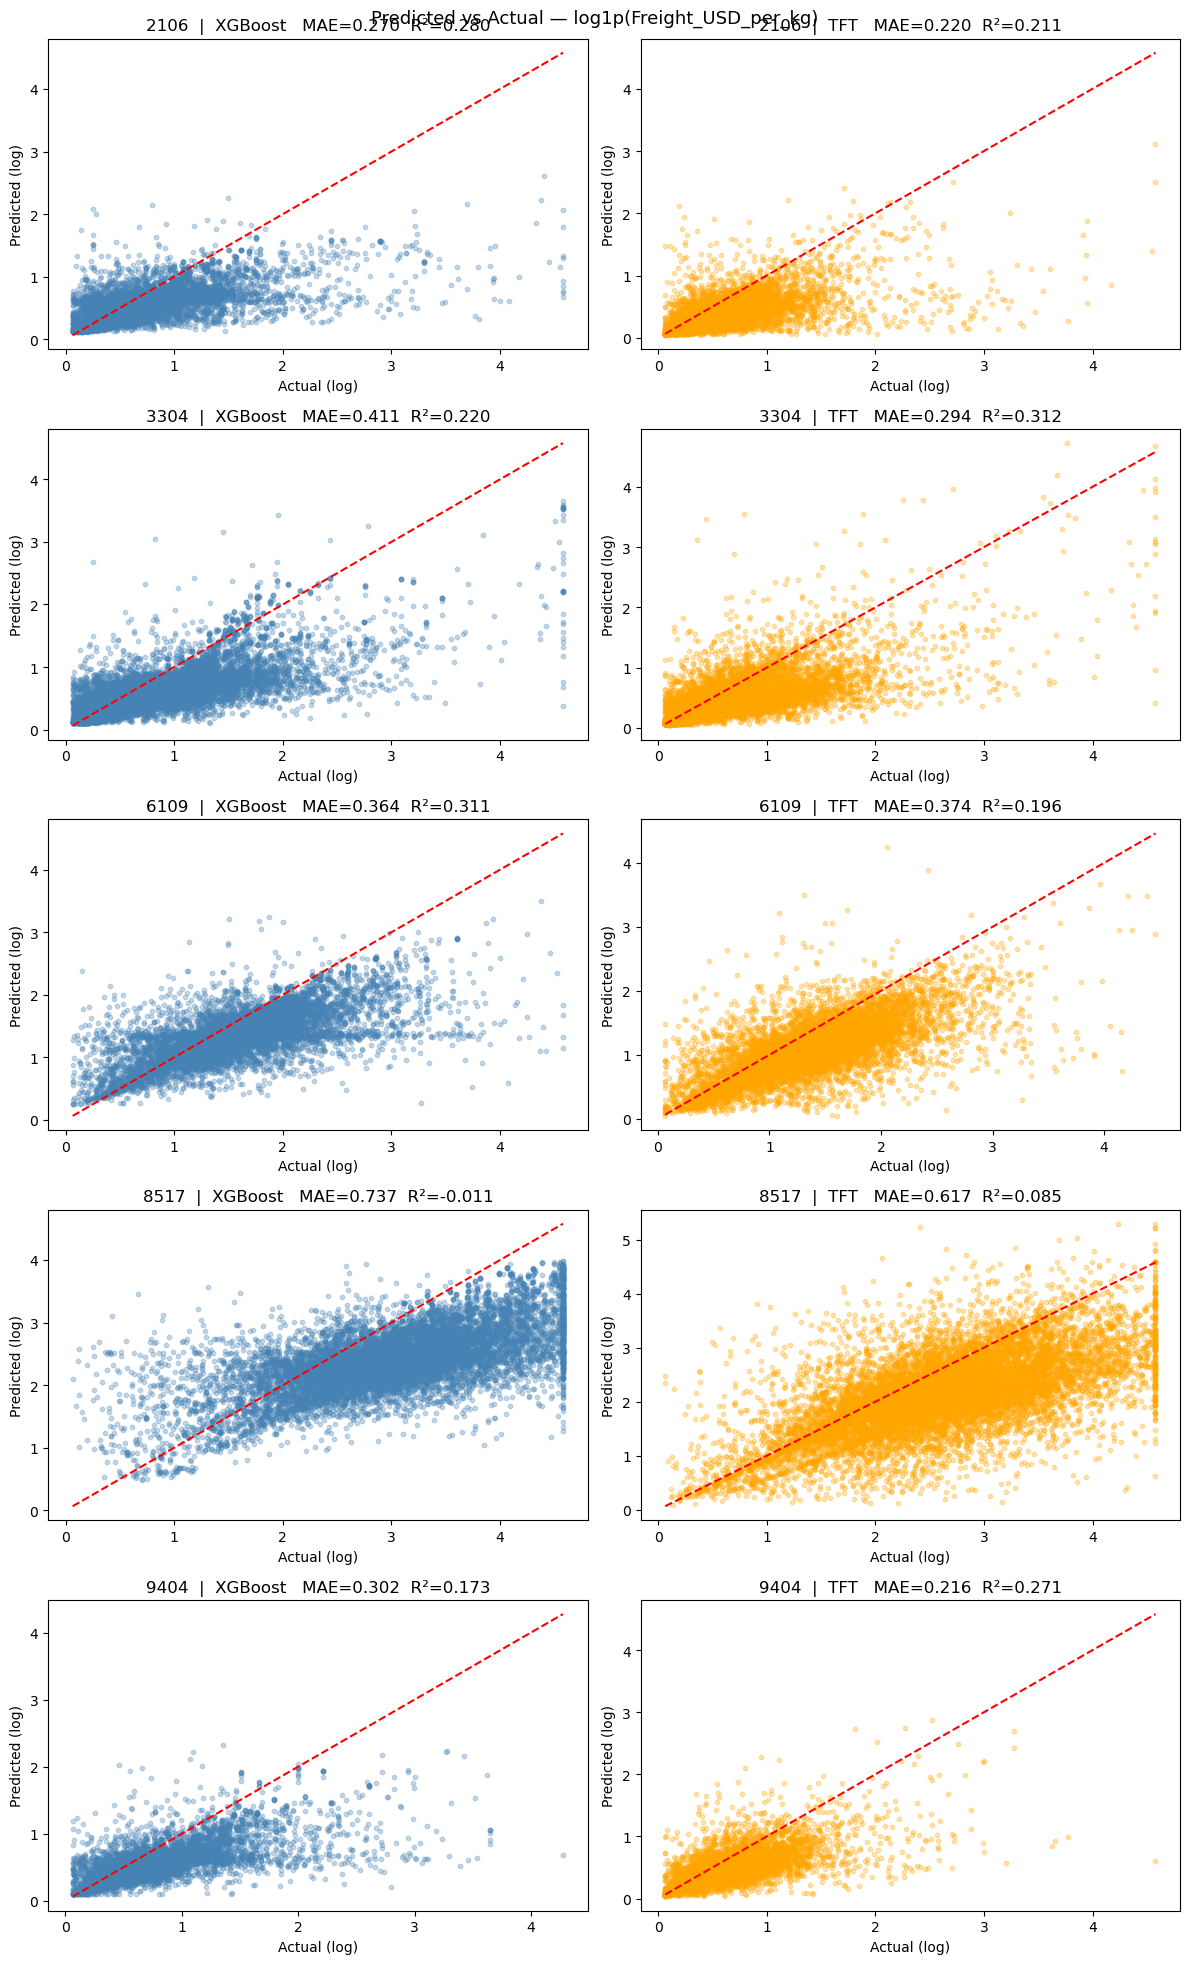

In [63]:

# ── 1. Side-by-side MAE bar chart: XGBoost vs TFT per product ────────────────
_prods    = list(pipeline_results.keys())
_x        = np.arange(len(_prods))
_w        = 0.35
_xgb_mlog = [pipeline_results[p]["xgb_metrics"]["mae_log"]  for p in _prods]
_tft_mlog = [pipeline_results[p]["tft_metrics"]["mae_log"]
             if pipeline_results[p]["tft_metrics"] else float("nan") for p in _prods]
_xgb_musd = [pipeline_results[p]["xgb_metrics"]["mae_usd"]  for p in _prods]
_tft_musd = [pipeline_results[p]["tft_metrics"]["mae_usd"]
             if pipeline_results[p]["tft_metrics"] else float("nan") for p in _prods]

fig, axes = plt.subplots(1, 2, figsize=(max(10, len(_prods) * 2), 4))

axes[0].bar(_x - _w/2, _xgb_mlog, _w, label="XGBoost", color="steelblue")
axes[0].bar(_x + _w/2, _tft_mlog, _w, label="TFT",     color="orange")
axes[0].set_xticks(_x); axes[0].set_xticklabels(_prods, rotation=15)
axes[0].set_ylabel("MAE (log scale)")
axes[0].set_title("Per-Product MAE — Log Scale")
axes[0].legend()

axes[1].bar(_x - _w/2, _xgb_musd, _w, label="XGBoost", color="steelblue")
axes[1].bar(_x + _w/2, _tft_musd, _w, label="TFT",     color="orange")
axes[1].set_xticks(_x); axes[1].set_xticklabels(_prods, rotation=15)
axes[1].set_ylabel("MAE (USD/kg)")
axes[1].set_title("Per-Product MAE — USD/kg Scale")
axes[1].legend()

plt.suptitle("Per-Product MAE: XGBoost vs TFT", fontsize=13)
plt.tight_layout()
plt.show()

# ── 2. Predicted vs Actual scatter — one row per product ─────────────────────
_n   = len(pipeline_results)
fig, axes = plt.subplots(_n, 2, figsize=(12, 4 * _n), squeeze=False)

for _i, (_prod, _res) in enumerate(pipeline_results.items()):
    _yt  = _res["df_test"][TARGET].values
    _yxp = _res["xgb_pred"]
    _lo, _hi = float(_yt.min()), float(_yt.max())

    axes[_i, 0].scatter(_yt, _yxp, alpha=0.3, s=10, color="steelblue")
    axes[_i, 0].plot([_lo, _hi], [_lo, _hi], "r--")
    axes[_i, 0].set_title(
        f"{_prod}  |  XGBoost   MAE={_res['xgb_metrics']['mae_log']:.3f}  "
        f"R²={_res['xgb_metrics']['r2_log']:.3f}")
    axes[_i, 0].set_xlabel("Actual (log)"); axes[_i, 0].set_ylabel("Predicted (log)")

    if _res["tft_aligned"] is not None:
        _ya = _res["tft_aligned"][TARGET].values
        _yp = _res["tft_aligned"]["y_pred"].values
        _lo2, _hi2 = float(_ya.min()), float(_ya.max())
        axes[_i, 1].scatter(_ya, _yp, alpha=0.3, s=10, color="orange")
        axes[_i, 1].plot([_lo2, _hi2], [_lo2, _hi2], "r--")
        axes[_i, 1].set_title(
            f"{_prod}  |  TFT   MAE={_res['tft_metrics']['mae_log']:.3f}  "
            f"R²={_res['tft_metrics']['r2_log']:.3f}")
    else:
        axes[_i, 1].text(0.5, 0.5, "TFT skipped\n(< 2 series)",
                         ha="center", va="center", transform=axes[_i, 1].transAxes)
        axes[_i, 1].set_title(f"{_prod}  |  TFT — not run")
    axes[_i, 1].set_xlabel("Actual (log)"); axes[_i, 1].set_ylabel("Predicted (log)")

plt.suptitle("Predicted vs Actual — log1p(Freight_USD_per_kg)", fontsize=13)
plt.tight_layout()
plt.show()


## New Route Prediction — Option A (KNN Analog Imputation)

For a route with **no historical observations**, lag features (`target_lag_1/2/3`, `target_rolling_mean_3`) cannot be computed directly. **Option A** resolves this by:

1. Representing each known route as a vector of time-averaged structural features (`dist_km`, `lsci_sum`, `lsbci`, `GDP_o`, `GDP_d`).
2. Finding the *k* nearest-neighbor routes for the new pair using the pre-fit `route_knn` model for that product.
3. Using the neighbors' mean `y_log` as the lag proxy — a data-driven estimate grounded in structurally similar corridors.

All structural features (distance, LSCI, LSBCI, GDP, GNI, CPI, fuel) are looked up directly from the source tables, so no prior freight observation is required. TFT is **not applicable** for new routes (requires a historical series); only XGBoost is used.


In [74]:
import random

PREDICT_YEAR    = 2022
# ── Set to specific values, or leave None to auto-select ─────────────────────
NEW_ORIGIN      = None   # e.g. "Singapore"
NEW_DESTINATION = None   # e.g. "Brazil"
NEW_PRODUCT     = None   # e.g. leave None to use first available product

# ── Helper: safe label-encoder lookup ────────────────────────────────────────
def _safe_encode(encoder, value):
    classes = list(encoder.classes_)
    return classes.index(value) if value in classes else 0

# ── Helper: look up a scalar value from a reference DataFrame ─────────────────
def _lookup(ref_df, label_col, label_val, year_col, year_val, val_col, fallback):
    row = ref_df[(ref_df[label_col] == label_val) & (ref_df[year_col] == year_val)]
    return float(row[val_col].iloc[0]) if len(row) > 0 else fallback

# ── 1. Select product and a NEW (unseen) O-D pair ────────────────────────────
_available_products = [p for p, r in pipeline_results.items() if r["xgb_model"] is not None]
if not _available_products:
    raise RuntimeError("No products found in pipeline_results — run the pipeline first.")

if NEW_PRODUCT is None:
    NEW_PRODUCT = _available_products[0]

_existing_routes = set(
    zip(
        df_model[df_model["Product_Code"] == NEW_PRODUCT]["Origin_Label"],
        df_model[df_model["Product_Code"] == NEW_PRODUCT]["Destination_Label"],
    )
)

if NEW_ORIGIN is None or NEW_DESTINATION is None:
    # Pick an O-D pair known to label encoders but absent for this product
    _known_origins = list(le_origin.classes_)
    _known_dests   = list(le_dest.classes_)
    _candidates = [
        (o, d) for o in _known_origins for d in _known_dests
        if (o, d) not in _existing_routes and o != d
    ]
    if not _candidates:
        raise RuntimeError("All known O-D combinations already exist for this product.")
    random.seed()
    NEW_ORIGIN, NEW_DESTINATION = random.choice(_candidates)

print(f"New route to predict:")
print(f"  Product    : {NEW_PRODUCT}")
print(f"  Origin     : {NEW_ORIGIN}")
print(f"  Destination: {NEW_DESTINATION}")
print(f"  Year       : {PREDICT_YEAR}")
print(f"  Status     : No historical data in training set")
print()

# ── 2. Assemble structural features from lookup tables ───────────────────────
iso_o = to_iso3(NEW_ORIGIN)
iso_d = to_iso3(NEW_DESTINATION)

feat_raw = {}

# Distance
_d_row = dist2[(dist2["iso_o"] == iso_o) & (dist2["iso_d"] == iso_d)]
feat_raw["dist_km"] = float(_d_row["dist_km"].iloc[0]) if len(_d_row) > 0 else dist_median

# LSBCI
_lb = lsbci2[(lsbci2["iso_o"] == iso_o) & (lsbci2["iso_d"] == iso_d)]
feat_raw["lsbci"] = float(_lb["lsbci"].iloc[0]) if len(_lb) > 0 else 0.0

# LSCI
_lo = lsci_year[(lsci_year["iso3"] == iso_o) & (lsci_year["Year"] == PREDICT_YEAR)]
_ld = lsci_year[(lsci_year["iso3"] == iso_d) & (lsci_year["Year"] == PREDICT_YEAR)]
feat_raw["lsci_o"]   = float(_lo["lsci"].iloc[0]) if len(_lo) > 0 else lsci_global_mean
feat_raw["lsci_d"]   = float(_ld["lsci"].iloc[0]) if len(_ld) > 0 else lsci_global_mean
feat_raw["lsci_sum"] = feat_raw["lsci_o"] + feat_raw["lsci_d"]
feat_raw["lsci_gap"] = abs(feat_raw["lsci_o"] - feat_raw["lsci_d"])

# Fuel
_f_row = fuel_year[fuel_year["Year"] == PREDICT_YEAR]
feat_raw["fuel_vlsfo_avg"] = float(_f_row["fuel_vlsfo_avg"].iloc[0]) if len(_f_row) > 0 else fuel_fill

# CPI
_cpi_fallback = float(df_cpi["Annual_average_growth_rate_Value"].median())
feat_raw["Source_CPI_Annual_average_growth_rate_Value"]      = _lookup(
    df_cpi, "Economy_Label", NEW_ORIGIN,      "Year", PREDICT_YEAR,
    "Annual_average_growth_rate_Value", _cpi_fallback)
feat_raw["Destination_CPI_Annual_average_growth_rate_Value"] = _lookup(
    df_cpi, "Economy_Label", NEW_DESTINATION, "Year", PREDICT_YEAR,
    "Annual_average_growth_rate_Value", _cpi_fallback)

# GDP
_gdp_fallback = float(df_gdp["US_at_current_prices_in_millions_Value"].median())
feat_raw["Source_GDP_US_at_current_prices_in_millions_Value"]      = _lookup(
    df_gdp, "Economy_Label", NEW_ORIGIN,      "Year", PREDICT_YEAR,
    "US_at_current_prices_in_millions_Value", _gdp_fallback)
feat_raw["Destination_GDP_US_at_current_prices_in_millions_Value"] = _lookup(
    df_gdp, "Economy_Label", NEW_DESTINATION, "Year", PREDICT_YEAR,
    "US_at_current_prices_in_millions_Value", _gdp_fallback)

# GNI
_gni_fallback = float(df_gni["US_dollars_at_current_prices_in_millions_Value"].median())
feat_raw["Source_GNI_US_dollars_at_current_prices_in_millions_Value"]      = _lookup(
    df_gni, "Economy_Label", NEW_ORIGIN,      "Year", PREDICT_YEAR,
    "US_dollars_at_current_prices_in_millions_Value", _gni_fallback)
feat_raw["Destination_GNI_US_dollars_at_current_prices_in_millions_Value"] = _lookup(
    df_gni, "Economy_Label", NEW_DESTINATION, "Year", PREDICT_YEAR,
    "US_dollars_at_current_prices_in_millions_Value", _gni_fallback)

# ── Cell 27 Features: Port Throughput (TEU) ──────────────────────────────────
try:
    teu_path = f"{data_path}/../data/raw/container_port_throughput.csv"
    df_teu_pred = pd.read_csv(teu_path)
    df_teu_pred = df_teu_pred[df_teu_pred["Economy_Label"] != "Individual economies"].copy()
    teu_cols = [c for c in df_teu_pred.columns if "TEU_Twenty_foot_Equivalent_Unit_Value" in c and c[:4].isdigit()]
    df_teu_pred = df_teu_pred.melt(id_vars=["Economy_Label"], value_vars=teu_cols, var_name="_col", value_name="teu")
    df_teu_pred["Year"] = df_teu_pred["_col"].str[:4].astype(int)
    df_teu_pred["teu"] = pd.to_numeric(df_teu_pred["teu"], errors="coerce")
    df_teu_pred["iso3"] = df_teu_pred["Economy_Label"].map(to_iso3)
    df_teu_pred = df_teu_pred.dropna(subset=["iso3"])
    
    _teu_o = df_teu_pred[(df_teu_pred["iso3"] == iso_o) & (df_teu_pred["Year"] == PREDICT_YEAR)]
    _teu_d = df_teu_pred[(df_teu_pred["iso3"] == iso_d) & (df_teu_pred["Year"] == PREDICT_YEAR)]
    feat_raw["origin_teu"] = float(_teu_o["teu"].iloc[0]) if len(_teu_o) > 0 and not pd.isna(_teu_o["teu"].iloc[0]) else 0.0
    feat_raw["dest_teu"] = float(_teu_d["teu"].iloc[0]) if len(_teu_d) > 0 and not pd.isna(_teu_d["teu"].iloc[0]) else 0.0
    feat_raw["origin_teu_is_imputed"] = 1 if feat_raw["origin_teu"] == 0.0 else 0
    feat_raw["dest_teu_is_imputed"] = 1 if feat_raw["dest_teu"] == 0.0 else 0
except Exception:
    feat_raw["origin_teu"] = 0.0
    feat_raw["dest_teu"] = 0.0
    feat_raw["origin_teu_is_imputed"] = 1
    feat_raw["dest_teu_is_imputed"] = 1

feat_raw["teu_log_product"] = np.log1p(feat_raw["origin_teu"]) * np.log1p(feat_raw["dest_teu"])

# ── Cell 27 Features: Merchant Fleet ─────────────────────────────────────────
try:
    fleet_path = f"{data_path}/../data/raw/merchant_fleet.csv"
    df_fleet_pred = pd.read_csv(fleet_path)
    df_fleet_pred = df_fleet_pred[df_fleet_pred["Economy_Label"] != "Individual economies"].copy()
    fleet_cols = [c for c in df_fleet_pred.columns if "DWT_Deadweight_tonnage_Value" in c and c[:4].isdigit()]
    df_fleet_pred = df_fleet_pred.melt(id_vars=["Economy_Label"], value_vars=fleet_cols, var_name="_col", value_name="fleet_dwt")
    df_fleet_pred["Year"] = df_fleet_pred["_col"].str[:4].astype(int)
    df_fleet_pred["fleet_dwt"] = pd.to_numeric(df_fleet_pred["fleet_dwt"], errors="coerce")
    df_fleet_pred["iso3"] = df_fleet_pred["Economy_Label"].map(to_iso3)
    df_fleet_pred = df_fleet_pred.dropna(subset=["iso3"])
    
    _fleet_o = df_fleet_pred[(df_fleet_pred["iso3"] == iso_o) & (df_fleet_pred["Year"] == PREDICT_YEAR)]
    _fleet_d = df_fleet_pred[(df_fleet_pred["iso3"] == iso_d) & (df_fleet_pred["Year"] == PREDICT_YEAR)]
    _fleet_total = df_fleet_pred[df_fleet_pred["Year"] == PREDICT_YEAR]["fleet_dwt"].sum()
    feat_raw["origin_fleet_pct"] = (float(_fleet_o["fleet_dwt"].iloc[0]) / _fleet_total * 100) if len(_fleet_o) > 0 and _fleet_total > 0 else 0.0
    feat_raw["dest_fleet_pct"] = (float(_fleet_d["fleet_dwt"].iloc[0]) / _fleet_total * 100) if len(_fleet_d) > 0 and _fleet_total > 0 else 0.0
except Exception:
    feat_raw["origin_fleet_pct"] = 0.0
    feat_raw["dest_fleet_pct"] = 0.0

feat_raw["fleet_supply"] = feat_raw["origin_fleet_pct"] + feat_raw["dest_fleet_pct"]

# ── Cell 27 Features: Seaborne Trade ─────────────────────────────────────────
try:
    trade_path = f"{data_path}/../data/raw/seaborne_trade.csv"
    df_trade_pred = pd.read_csv(trade_path)
    df_trade_pred = df_trade_pred[df_trade_pred["Economy_Label"] != "Individual economies"].copy()
    df_trade_pred["iso3"] = df_trade_pred["Economy_Label"].map(to_iso3)
    df_trade_pred = df_trade_pred.dropna(subset=["iso3"])
    trade_cols = [c for c in df_trade_pred.columns if "_Value" in c and c[:4].isdigit()]
    df_trade_long = df_trade_pred.melt(id_vars=["iso3", "Indicator_Label"], value_vars=trade_cols, var_name="_col", value_name="value")
    df_trade_long["Year"] = df_trade_long["_col"].str[:4].astype(int)
    df_trade_long["value"] = pd.to_numeric(df_trade_long["value"], errors="coerce")
    df_trade_pivot = df_trade_long.pivot_table(index=["iso3", "Year"], columns="Indicator_Label", values="value", aggfunc="first").reset_index()
    
    _trade_o = df_trade_pivot[(df_trade_pivot["iso3"] == iso_o) & (df_trade_pivot["Year"] == PREDICT_YEAR)]
    _trade_d = df_trade_pivot[(df_trade_pivot["iso3"] == iso_d) & (df_trade_pivot["Year"] == PREDICT_YEAR)]
    feat_raw["origin_loaded_kt"] = float(_trade_o["Goods loaded (thousand tonnes)"].iloc[0]) if len(_trade_o) > 0 and "Goods loaded (thousand tonnes)" in _trade_o.columns else 0.0
    feat_raw["origin_discharged_kt"] = float(_trade_o["Goods discharged (thousand tonnes)"].iloc[0]) if len(_trade_o) > 0 and "Goods discharged (thousand tonnes)" in _trade_o.columns else 0.0
    feat_raw["dest_loaded_kt"] = float(_trade_d["Goods loaded (thousand tonnes)"].iloc[0]) if len(_trade_d) > 0 and "Goods loaded (thousand tonnes)" in _trade_d.columns else 0.0
    feat_raw["dest_discharged_kt"] = float(_trade_d["Goods discharged (thousand tonnes)"].iloc[0]) if len(_trade_d) > 0 and "Goods discharged (thousand tonnes)" in _trade_d.columns else 0.0
except Exception:
    feat_raw["origin_loaded_kt"] = 0.0
    feat_raw["origin_discharged_kt"] = 0.0
    feat_raw["dest_loaded_kt"] = 0.0
    feat_raw["dest_discharged_kt"] = 0.0

feat_raw["trade_imbalance"] = (
    (feat_raw["origin_loaded_kt"] - feat_raw["dest_loaded_kt"]) 
    / (feat_raw["origin_loaded_kt"] + feat_raw["dest_loaded_kt"] + 1e-9)
)

# ── Cell 27 Features: Vessel Percentages ─────────────────────────────────────
try:
    vessel_path = f"{data_path}/../data/raw/vessel_percent_of_global_fleet.csv"
    df_vessel_pred = pd.read_csv(vessel_path)
    df_vessel_pred = df_vessel_pred[df_vessel_pred["FlagOfRegistration_Label"] != "Individual economies"].copy()
    vessel_cols = [c for c in df_vessel_pred.columns if "Percentage_of_global_fleet_value_Value" in c and c[:4].isdigit()]
    df_vessel_pred = df_vessel_pred.melt(id_vars=["FlagOfRegistration_Label"], value_vars=vessel_cols, var_name="_col", value_name="vessel_pct")
    df_vessel_pred["Year"] = df_vessel_pred["_col"].str[:4].astype(int)
    df_vessel_pred["vessel_pct"] = pd.to_numeric(df_vessel_pred["vessel_pct"], errors="coerce")
    df_vessel_pred["iso3"] = df_vessel_pred["FlagOfRegistration_Label"].map(to_iso3)
    df_vessel_pred = df_vessel_pred.dropna(subset=["iso3"])
    
    _vessel_o = df_vessel_pred[(df_vessel_pred["iso3"] == iso_o) & (df_vessel_pred["Year"] == PREDICT_YEAR)]
    _vessel_d = df_vessel_pred[(df_vessel_pred["iso3"] == iso_d) & (df_vessel_pred["Year"] == PREDICT_YEAR)]
    feat_raw["origin_vessel_pct"] = float(_vessel_o["vessel_pct"].iloc[0]) if len(_vessel_o) > 0 and not pd.isna(_vessel_o["vessel_pct"].iloc[0]) else 0.0
    feat_raw["dest_vessel_pct"] = float(_vessel_d["vessel_pct"].iloc[0]) if len(_vessel_d) > 0 and not pd.isna(_vessel_d["vessel_pct"].iloc[0]) else 0.0
except Exception:
    feat_raw["origin_vessel_pct"] = 0.0
    feat_raw["dest_vessel_pct"] = 0.0

# ── Cell 27 Features: Historical Mean Rate ───────────────────────────────────
# For new routes, use product median from historical data (2016-2019)
try:
    _hist_subset = df_model[
        (df_model["Product_Code"] == NEW_PRODUCT) & 
        (df_model["Year"].isin([2016, 2017, 2018, 2019]))
    ]
    if len(_hist_subset) > 0:
        feat_raw["historical_mean_rate"] = float(np.expm1(_hist_subset[TARGET].median()))
        feat_raw["historical_mean_rate_is_imputed"] = 1  # Always imputed for new routes
    else:
        feat_raw["historical_mean_rate"] = 0.0
        feat_raw["historical_mean_rate_is_imputed"] = 1
except Exception:
    feat_raw["historical_mean_rate"] = 0.0
    feat_raw["historical_mean_rate_is_imputed"] = 1

# ── Cell 27 Features: Derived Features ───────────────────────────────────────
feat_raw["lsci_asymmetry"] = abs(feat_raw["lsci_o"] - feat_raw["lsci_d"])
feat_raw["post_covid"] = 1 if PREDICT_YEAR >= 2020 else 0
feat_raw["year_int"] = int(PREDICT_YEAR)

# Product category encoding
try:
    _unique_products = sorted(df_model["Product_Code"].unique())
    feat_raw["product_cat"] = int(_unique_products.index(NEW_PRODUCT)) if NEW_PRODUCT in _unique_products else 0
except Exception:
    feat_raw["product_cat"] = 0

# LSBCI imputation flag
feat_raw["bilateral_lsci_is_imputed"] = 1 if feat_raw["lsbci"] == 0.0 else 0

print("Structural features assembled:")
for _fc in FEATURE_COLS:
    print(f"  {_fc:65s}: {feat_raw[_fc]:.4f}")
print()

# ── 3. Option A — KNN analog lag proxy ───────────────────────────────────────
_knn_info = route_knn.get(NEW_PRODUCT)

if _knn_info is not None:
    _query_raw    = np.array([[feat_raw.get(f, 0.0) for f in KNN_FEATS]])
    _query_scaled = _knn_info["knn_scaler"].transform(_query_raw)
    _, _nbr_idx   = _knn_info["knn"].kneighbors(_query_scaled)
    _neighbors    = _knn_info["route_means"].iloc[_nbr_idx[0]]
    _lag_proxy    = float(_neighbors[TARGET].mean())

    print(f"Option A — {len(_nbr_idx[0])} nearest analog route(s):")
    for _, _nr in _neighbors.iterrows():
        print(f"  {_nr['Origin_Label']:25s} → {_nr['Destination_Label']:25s}  "
              f"mean y_log={_nr[TARGET]:.4f}  ({np.expm1(_nr[TARGET]):.4f} USD/kg)")
    print(f"\n  Lag proxy (mean of neighbors): {_lag_proxy:.4f}  ({np.expm1(_lag_proxy):.4f} USD/kg)")
else:
    _lag_proxy = float(df_model[df_model["Product_Code"] == NEW_PRODUCT][TARGET].median())
    print(f"Option A fallback — product-level median proxy: {_lag_proxy:.4f}  "
          f"({np.expm1(_lag_proxy):.4f} USD/kg)")

feat_raw["target_lag_1"]          = _lag_proxy
feat_raw["target_lag_2"]          = _lag_proxy
feat_raw["target_lag_3"]          = _lag_proxy
feat_raw["target_rolling_mean_3"] = _lag_proxy
print()

# ── 4. Scale FEATURE_COLS with the product train-slice scaler ────────────────
_sub_p      = df_model[df_model["Product_Code"] == NEW_PRODUCT]
_df_train_p = _sub_p[_sub_p[TIME_COL] <= split_year]
_scaler     = StandardScaler().fit(_df_train_p[FEATURE_COLS])
_scaled     = _scaler.transform(
    np.array([[feat_raw[c] for c in FEATURE_COLS]])).flatten()

feat_row = {c: float(v) for c, v in zip(FEATURE_COLS, _scaled)}
feat_row["target_lag_1"]          = feat_raw["target_lag_1"]
feat_row["target_lag_2"]          = feat_raw["target_lag_2"]
feat_row["target_lag_3"]          = feat_raw["target_lag_3"]
feat_row["target_rolling_mean_3"] = feat_raw["target_rolling_mean_3"]
feat_row["origin_enc"]            = _safe_encode(le_origin,  NEW_ORIGIN)
feat_row["dest_enc"]              = _safe_encode(le_dest,    NEW_DESTINATION)
feat_row["product_enc"]           = _safe_encode(le_product, str(NEW_PRODUCT))
feat_row[TIME_COL]                = PREDICT_YEAR

X_pred = pd.DataFrame([feat_row])[XGB_FEATURES]

# ── 5. XGBoost prediction ─────────────────────────────────────────────────────
y_log_xgb   = float(pipeline_results[NEW_PRODUCT]["xgb_model"].predict(X_pred)[0])
freight_xgb = np.expm1(y_log_xgb)

print(f"── XGBoost Prediction (New Route, Option A) ─────────────")
print(f"  y_log   : {y_log_xgb:.4f}")
print(f"  Freight : {freight_xgb:.4f} USD/kg")
print()
print("Note: TFT requires a historical time-series and cannot be applied to new routes.")


New route to predict:
  Product    : 2106
  Origin     : Dominica
  Destination: Zambia
  Year       : 2022
  Status     : No historical data in training set

Structural features assembled:
  Source_CPI_Annual_average_growth_rate_Value                      : 7.4700
  Destination_CPI_Annual_average_growth_rate_Value                 : 10.9900
  Source_GDP_US_at_current_prices_in_millions_Value                : 623.0000
  Destination_GDP_US_at_current_prices_in_millions_Value           : 29164.0000
  Source_GNI_US_dollars_at_current_prices_in_millions_Value        : 24605.0000
  Destination_GNI_US_dollars_at_current_prices_in_millions_Value   : 24605.0000
  lsbci                                                            : 0.0000
  dist_km                                                          : 10403.5200
  fuel_vlsfo_avg                                                   : 828.8692
  lsci_o                                                           : 24.0250
  lsci_d                    

c:\Users\xianj\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\xianj\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
